# Employee Attrition Analytics

### by Balqis Bankole

## Business Context

Indicino is a digital payment company based in Accra Ghana. It operates a fully onsite work model and provides educational grants to  eligible employees. It has already tried several employee retention  initiatives. Recently, key staffs resigned and employee attrition increased significantly.

## Business Problem

Indicino is experiencing a significant increase in attrition despite implementing several retention initiatives, resulting in the loss of key employees. 
The company needs to understand the drivers of attrition  and identify which employees are at risk. 

## Objective

To identify the key factors driving employee attrition and develop evidence based recommendations that can help Indicino improve employee retention.

## Business Questions

1. Identify the root cause(s) of attrition in the company
2. Predict the Job roles that are likely to resign the current year and why?
3. What age band(s) are likely to  be retained
4. If you were the group head of Indicino's HR, what would you do differently
5. Does the length of stay with current manager have any impact on the reason(s) identified in 1
6. Give insights to the performance and reward culture at Indicino
7. Present your insights and recommendation with appropraite charts 


In [1]:
## Import Libraries

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')


from sklearn.model_selection import train_test_split 
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix,accuracy_score,precision_score,recall_score, f1_score
from imblearn.over_sampling import SMOTE

In [2]:
## Load data

df = pd.read_csv('/Users/balqis_b/Downloads/Indicino project.xlsx - Attrition_data.csv')

In [3]:
df.head(2)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7


In [4]:
pd.set_option('display.max_columns', None)

df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,$ 3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,$ 2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,$ 2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,$ 3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,$ 3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


## Data Inspection

I first examined the dataset structure, data types, missing values, duplicate records and basic descriptive statistics to asses the overrall quality of the dataset before beginning the analysis

In [5]:
df.shape

(1470, 35)

In [6]:
df.duplicated().sum()

0

In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,1470.0,36.923810,9.135373,18.0,30.00,36.0,43.00,60.0
DailyRate,1470.0,802.485714,403.509100,102.0,465.00,802.0,1157.00,1499.0
DistanceFromHome,1470.0,9.192517,8.106864,1.0,2.00,7.0,14.00,29.0
Education,1470.0,2.912925,1.024165,1.0,2.00,3.0,4.00,5.0
EmployeeCount,1470.0,1.000000,0.000000,1.0,1.00,1.0,1.00,1.0
EmployeeNumber,1470.0,1024.865306,602.024335,1.0,491.25,1020.5,1555.75,2068.0
EnvironmentSatisfaction,1470.0,2.721769,1.093082,1.0,2.00,3.0,4.00,4.0
HourlyRate,1470.0,65.891156,20.329428,30.0,48.00,66.0,83.75,100.0
JobLevel,1470.0,2.063946,1.106940,1.0,1.00,2.0,3.00,5.0
JobSatisfaction,1470.0,2.728571,1.102846,1.0,2.00,3.0,4.00,4.0


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13   JobInvolvement           1470 non-null   object
 14  JobLevel                

In [9]:
df_col = ['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       ' JobInvolvement ', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager']

for col in df_col:
    print(col, df[col].unique())

Age [41 49 37 33 27 32 59 30 38 36 35 29 31 34 28 22 53 24 21 42 44 46 39 43
 50 26 48 55 45 56 23 51 40 54 58 20 25 19 57 52 47 18 60]
Attrition ['Yes' 'No']
BusinessTravel ['Travel_Rarely' 'Travel_Frequently' 'Non-Travel']
DailyRate [1102  279 1373 1392  591 1005 1324 1358  216 1299  809  153  670 1346
  103 1389  334 1123 1219  371  673 1218  419  391  699 1282 1125  691
  477  705  924 1459  125  895  813 1273  869  890  852 1141  464 1240
 1357  994  721 1360 1065  408 1211 1229  626 1434 1488 1097 1443  515
  853 1142  655 1115  427  653  989 1435 1223  836 1195 1339  664  318
 1225 1328 1082  548  132  746  776  193  397  945 1214  111  573 1153
 1400  541  432  288  669  530  632 1334  638 1093 1217 1353  120  682
  489  807  827  871  665 1040 1420  240 1280  534 1456  658  142 1127
 1031 1189 1354 1467  922  394 1312  750  441  684  249  841  147  528
  594  470  957  542  802 1355 1150 1329  959 1033 1316  364  438  689
  201 1427  857  933 1181 1395  662 1436  194  967 1496

#### Initial Findings

The dataset contains 1470 observations and 35 variables. There are no duplicated customer records. Trailing spaces were observed in a variable JonInvolvement, which will need to be removed. JobInvolvement is also in the wrong format and contains inconsistencies. There is no variation in the values of EmployeeCount, Over18, and StandardHours, so these values should be removed.

## Data Cleaning

The following cleaning steps were performed:

- Removed trailing spaces from variable names.
- Removed the inconsistencies in JobInvolvement.
- Changed datatype of JobInvolvement from object to integer.
- Removed columns that were not useful for the analysis


In [10]:
df.columns=df.columns.str.strip()

In [11]:
df['JobInvolvement']=df['JobInvolvement'].str.replace('$', '', regex = False).str.strip()
df['JobInvolvement'].unique()

array(['3', '2', '4', '1'], dtype=object)

In [12]:
df.drop(['StandardHours','Over18','EmployeeCount','EmployeeNumber'],axis = 1, inplace = True)


In [13]:
df['JobInvolvement'] = df['JobInvolvement'].astype(int)
df['JobInvolvement']. dtype

dtype('int64')

In [14]:
df_col = ['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField','EnvironmentSatisfaction', 
        'Gender', 'HourlyRate','JobInvolvement','JobLevel', 'JobRole', 'JobSatisfaction',
        'MaritalStatus', 'MonthlyIncome','MonthlyRate', 'NumCompaniesWorked', 'OverTime', 
        'PercentSalaryHike','PerformanceRating','RelationshipSatisfaction','StockOptionLevel',
        'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance','YearsAtCompany', 
        'YearsInCurrentRole', 'YearsSinceLastPromotion','YearsWithCurrManager']

for col in df_col:
    print(col, df[col].unique())

Age [41 49 37 33 27 32 59 30 38 36 35 29 31 34 28 22 53 24 21 42 44 46 39 43
 50 26 48 55 45 56 23 51 40 54 58 20 25 19 57 52 47 18 60]
Attrition ['Yes' 'No']
BusinessTravel ['Travel_Rarely' 'Travel_Frequently' 'Non-Travel']
DailyRate [1102  279 1373 1392  591 1005 1324 1358  216 1299  809  153  670 1346
  103 1389  334 1123 1219  371  673 1218  419  391  699 1282 1125  691
  477  705  924 1459  125  895  813 1273  869  890  852 1141  464 1240
 1357  994  721 1360 1065  408 1211 1229  626 1434 1488 1097 1443  515
  853 1142  655 1115  427  653  989 1435 1223  836 1195 1339  664  318
 1225 1328 1082  548  132  746  776  193  397  945 1214  111  573 1153
 1400  541  432  288  669  530  632 1334  638 1093 1217 1353  120  682
  489  807  827  871  665 1040 1420  240 1280  534 1456  658  142 1127
 1031 1189 1354 1467  922  394 1312  750  441  684  249  841  147  528
  594  470  957  542  802 1355 1150 1329  959 1033 1316  364  438  689
  201 1427  857  933 1181 1395  662 1436  194  967 1496

## Question 1: Identifying the root cause(s) of attrition in the company
  

## Exploratory Data Analysis

In [15]:
df['Attrition'].value_counts()

Attrition
No     1233
Yes     237
Name: count, dtype: int64

In [16]:
df['Attrition'].value_counts(normalize=True) * 100

Attrition
No     83.877551
Yes    16.122449
Name: proportion, dtype: float64

#### Observation
16.1% of the employees left the company, compared to 83.9% who remained

In [17]:
### Creating a seperate variable for Categorical and numerial data for easy assessment

cat_cols = ['Attrition', 'BusinessTravel', 'Department', 'Education','EducationField','EnvironmentSatisfaction','Gender','JobInvolvement','JobLevel', 'JobRole', 'JobSatisfaction','MaritalStatus', 'OverTime', 'PercentSalaryHike','PerformanceRating','RelationshipSatisfaction','StockOptionLevel','TrainingTimesLastYear', 'WorkLifeBalance']

numeric = ['Age', 'DailyRate', 'Education','EnvironmentSatisfaction','JobLevel','JobSatisfaction','JobInvolvement','DistanceFromHome', 'HourlyRate', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked','PercentSalaryHike','RelationshipSatisfaction','StockOptionLevel','TotalWorkingYears','TrainingTimesLastYear', 'WorkLifeBalance','YearsAtCompany','YearsInCurrentRole', 'YearsSinceLastPromotion','YearsWithCurrManager']

numeric_cols = ['Age', 'DailyRate', 'DistanceFromHome', 'HourlyRate', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked','TotalWorkingYears','YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion','YearsWithCurrManager']


### Distribution of Categorical variables 

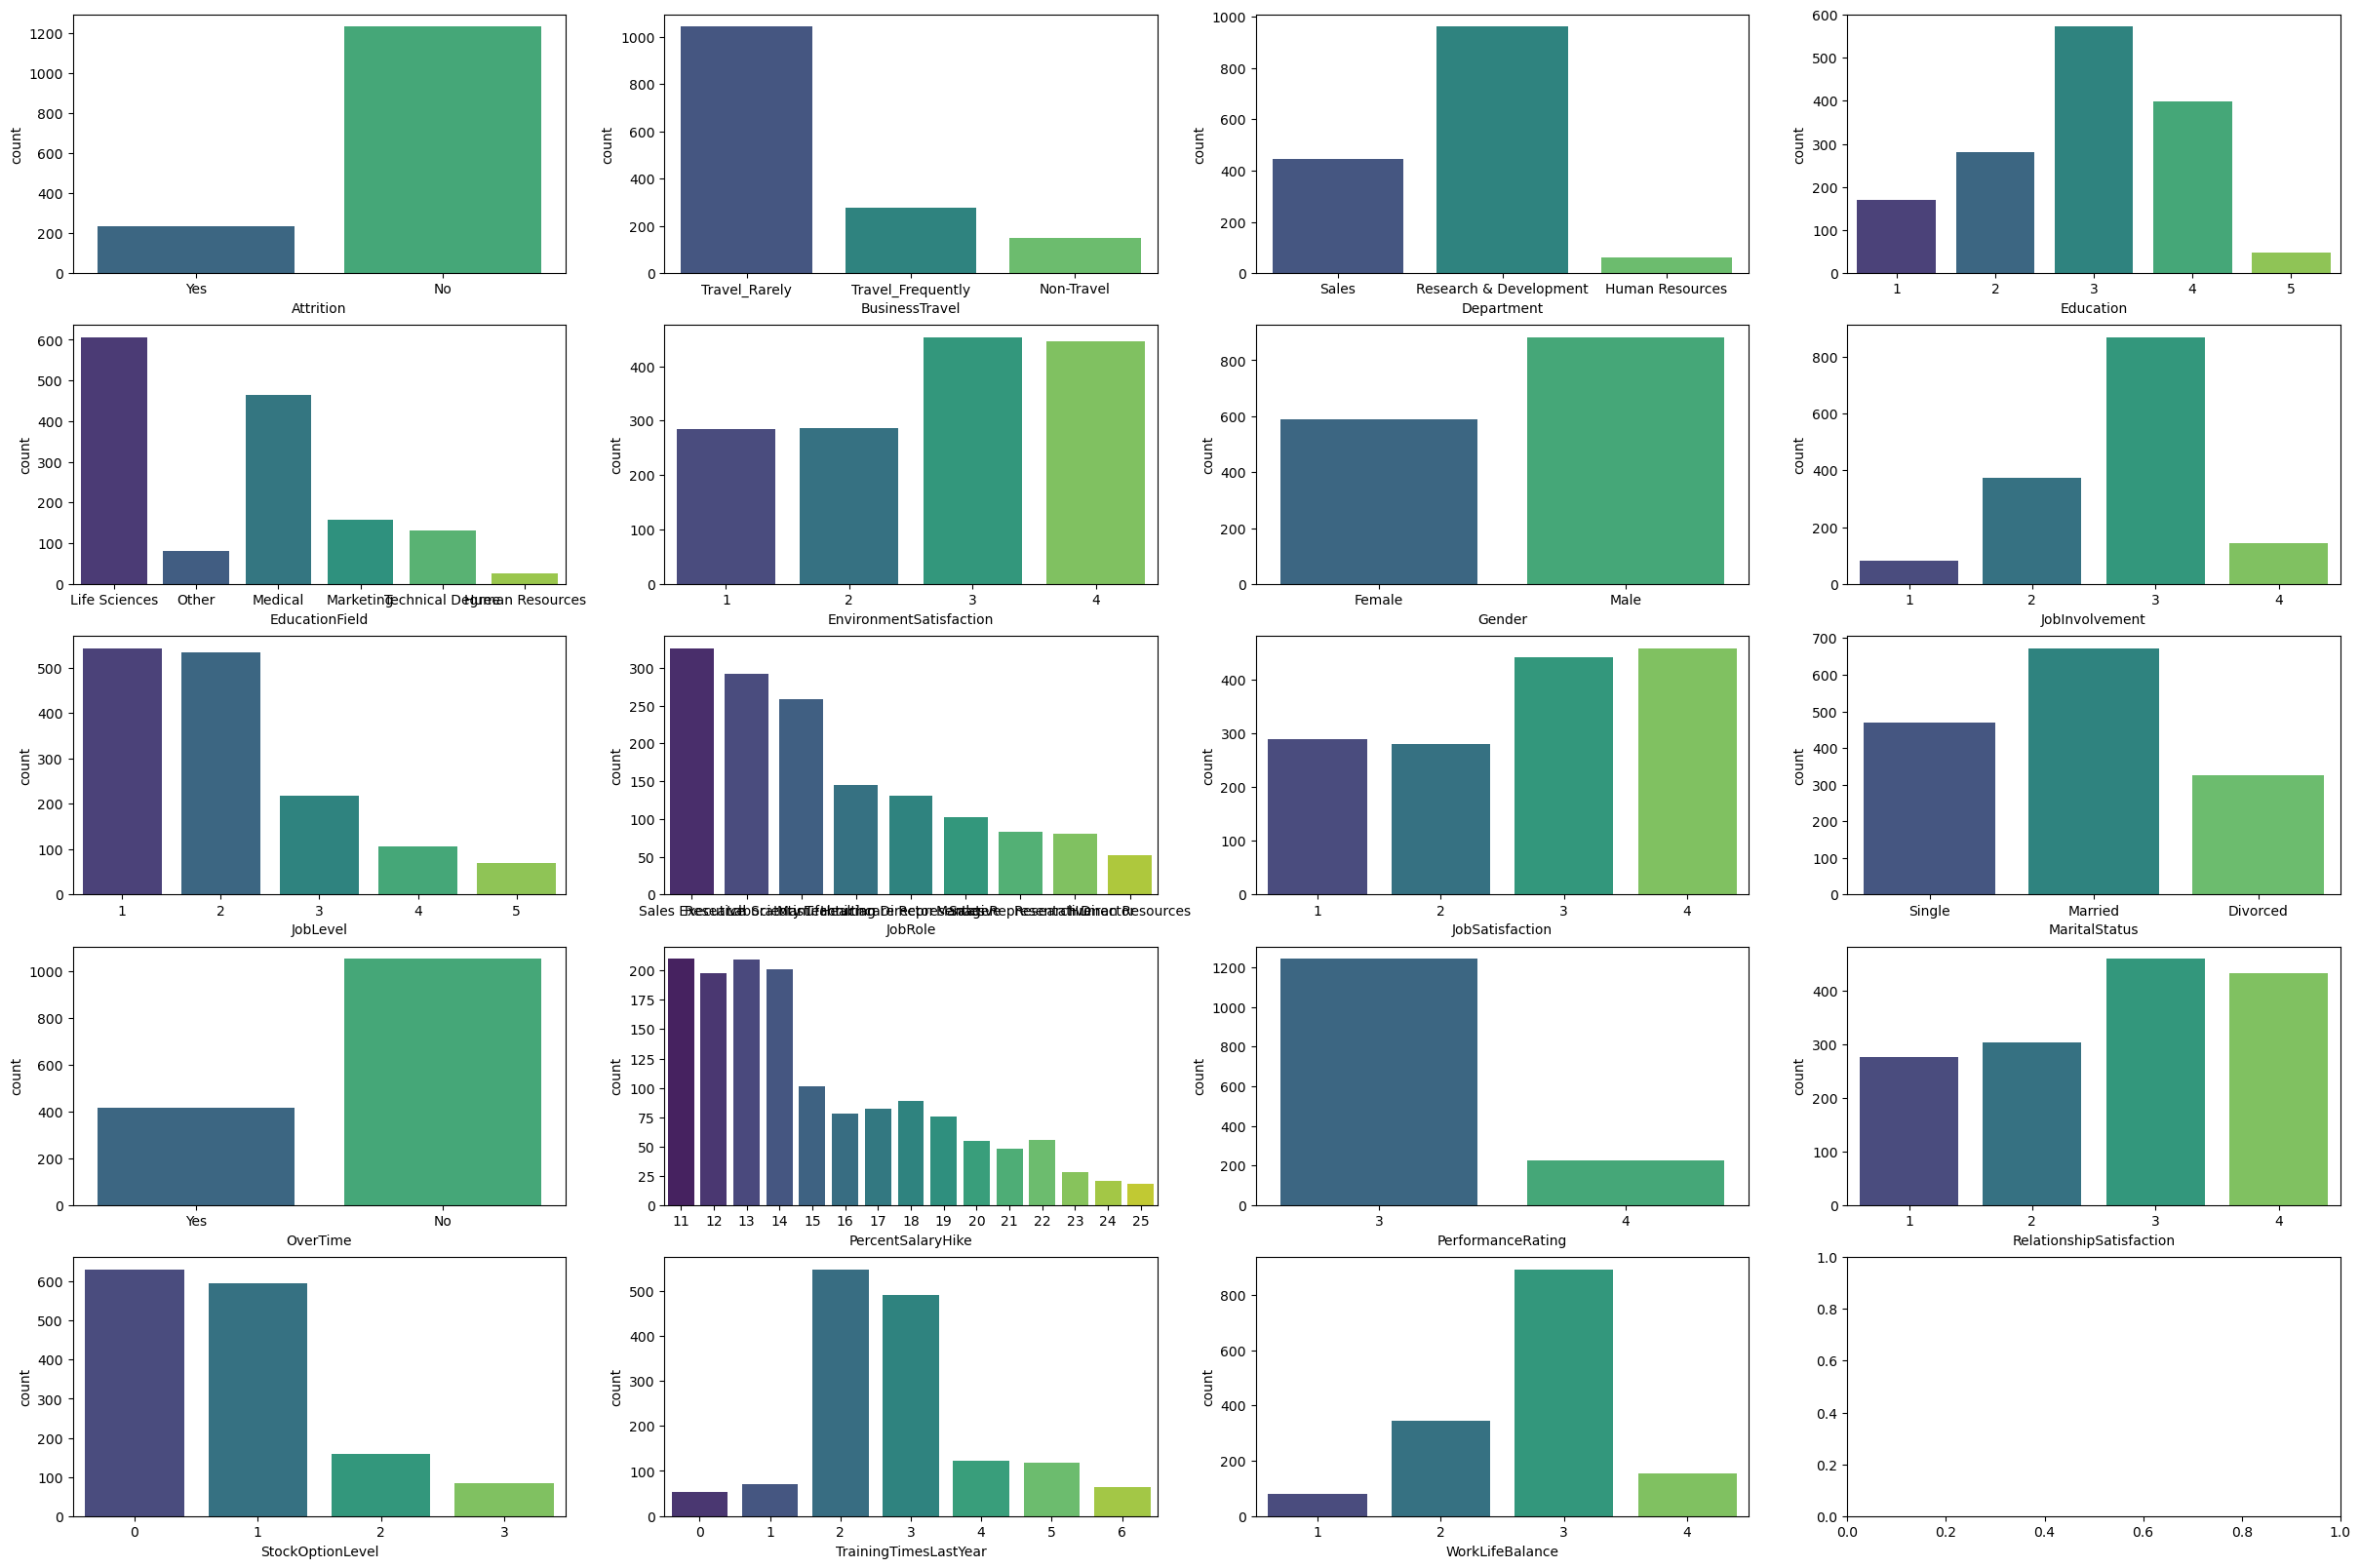

In [18]:
## Inspecting the categorical variable, what does each look like itself

fig, axes = plt.subplots(ncols = 4, nrows =5, figsize =(30,20))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.countplot(x = col, data = df, ax = axes[i], palette = 'viridis')

<Axes: xlabel='JobRole', ylabel='count'>

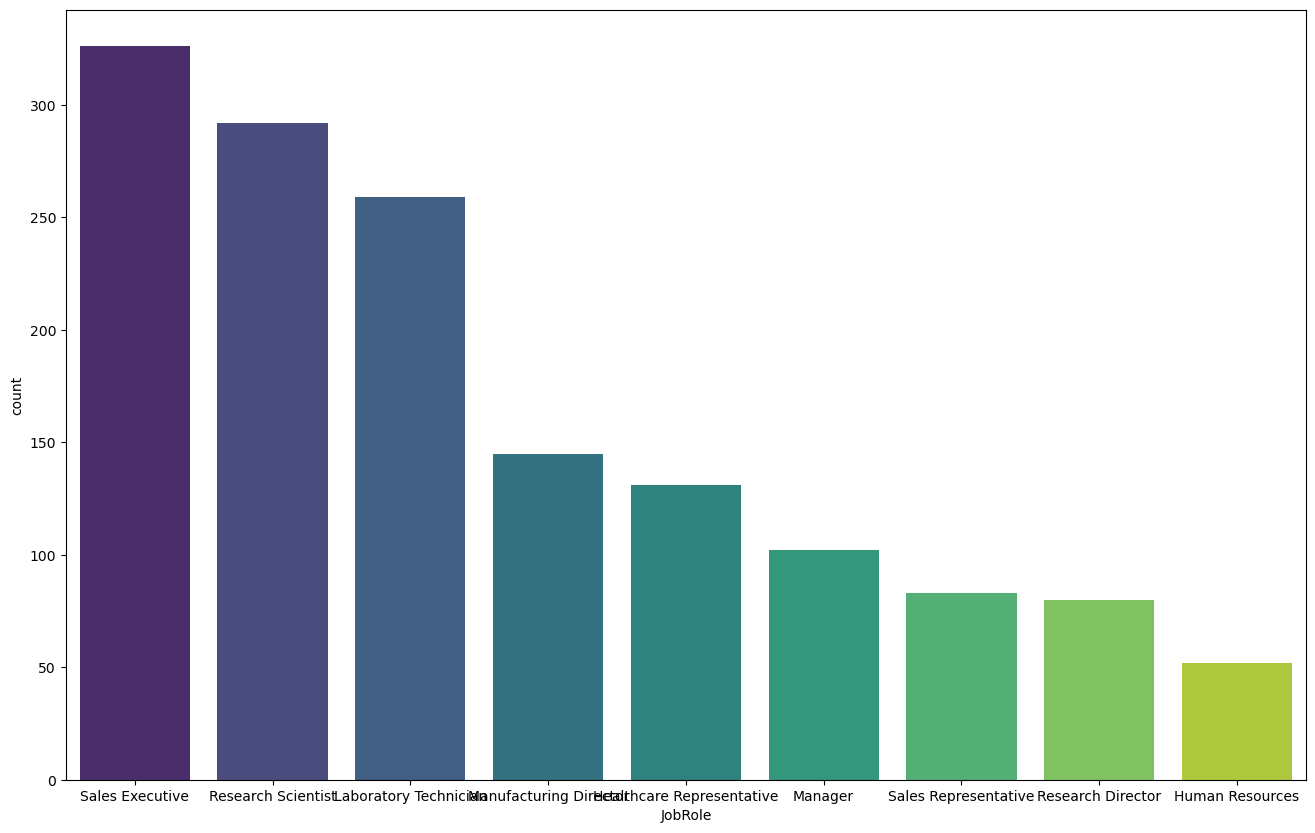

In [19]:
plt.figure(figsize=(16,10))
sns.countplot(x ='JobRole', data = df, palette = 'viridis')

#### Observation

It is observed that the workforce is predominantly Males, married, Travel rarely, located in the Research and Development department, from the lifesciences and medical fields, not working overtime, Staffs are mainly Sales execitives, Research Scientist and Laboratory Technicians, not working overtime and Mostly educated.
Most employees also appear to have: High job involvement, High job satisfaction, High environment satisfaction, High relationship satisfaction,Better work-life balance, Around 2–3 training sessions per year, Lower job levels, Relatively modest salary increases,Performance rating of 3, Stock option level 0 or 1.

### Distribution of all Categorical variables by Attrition

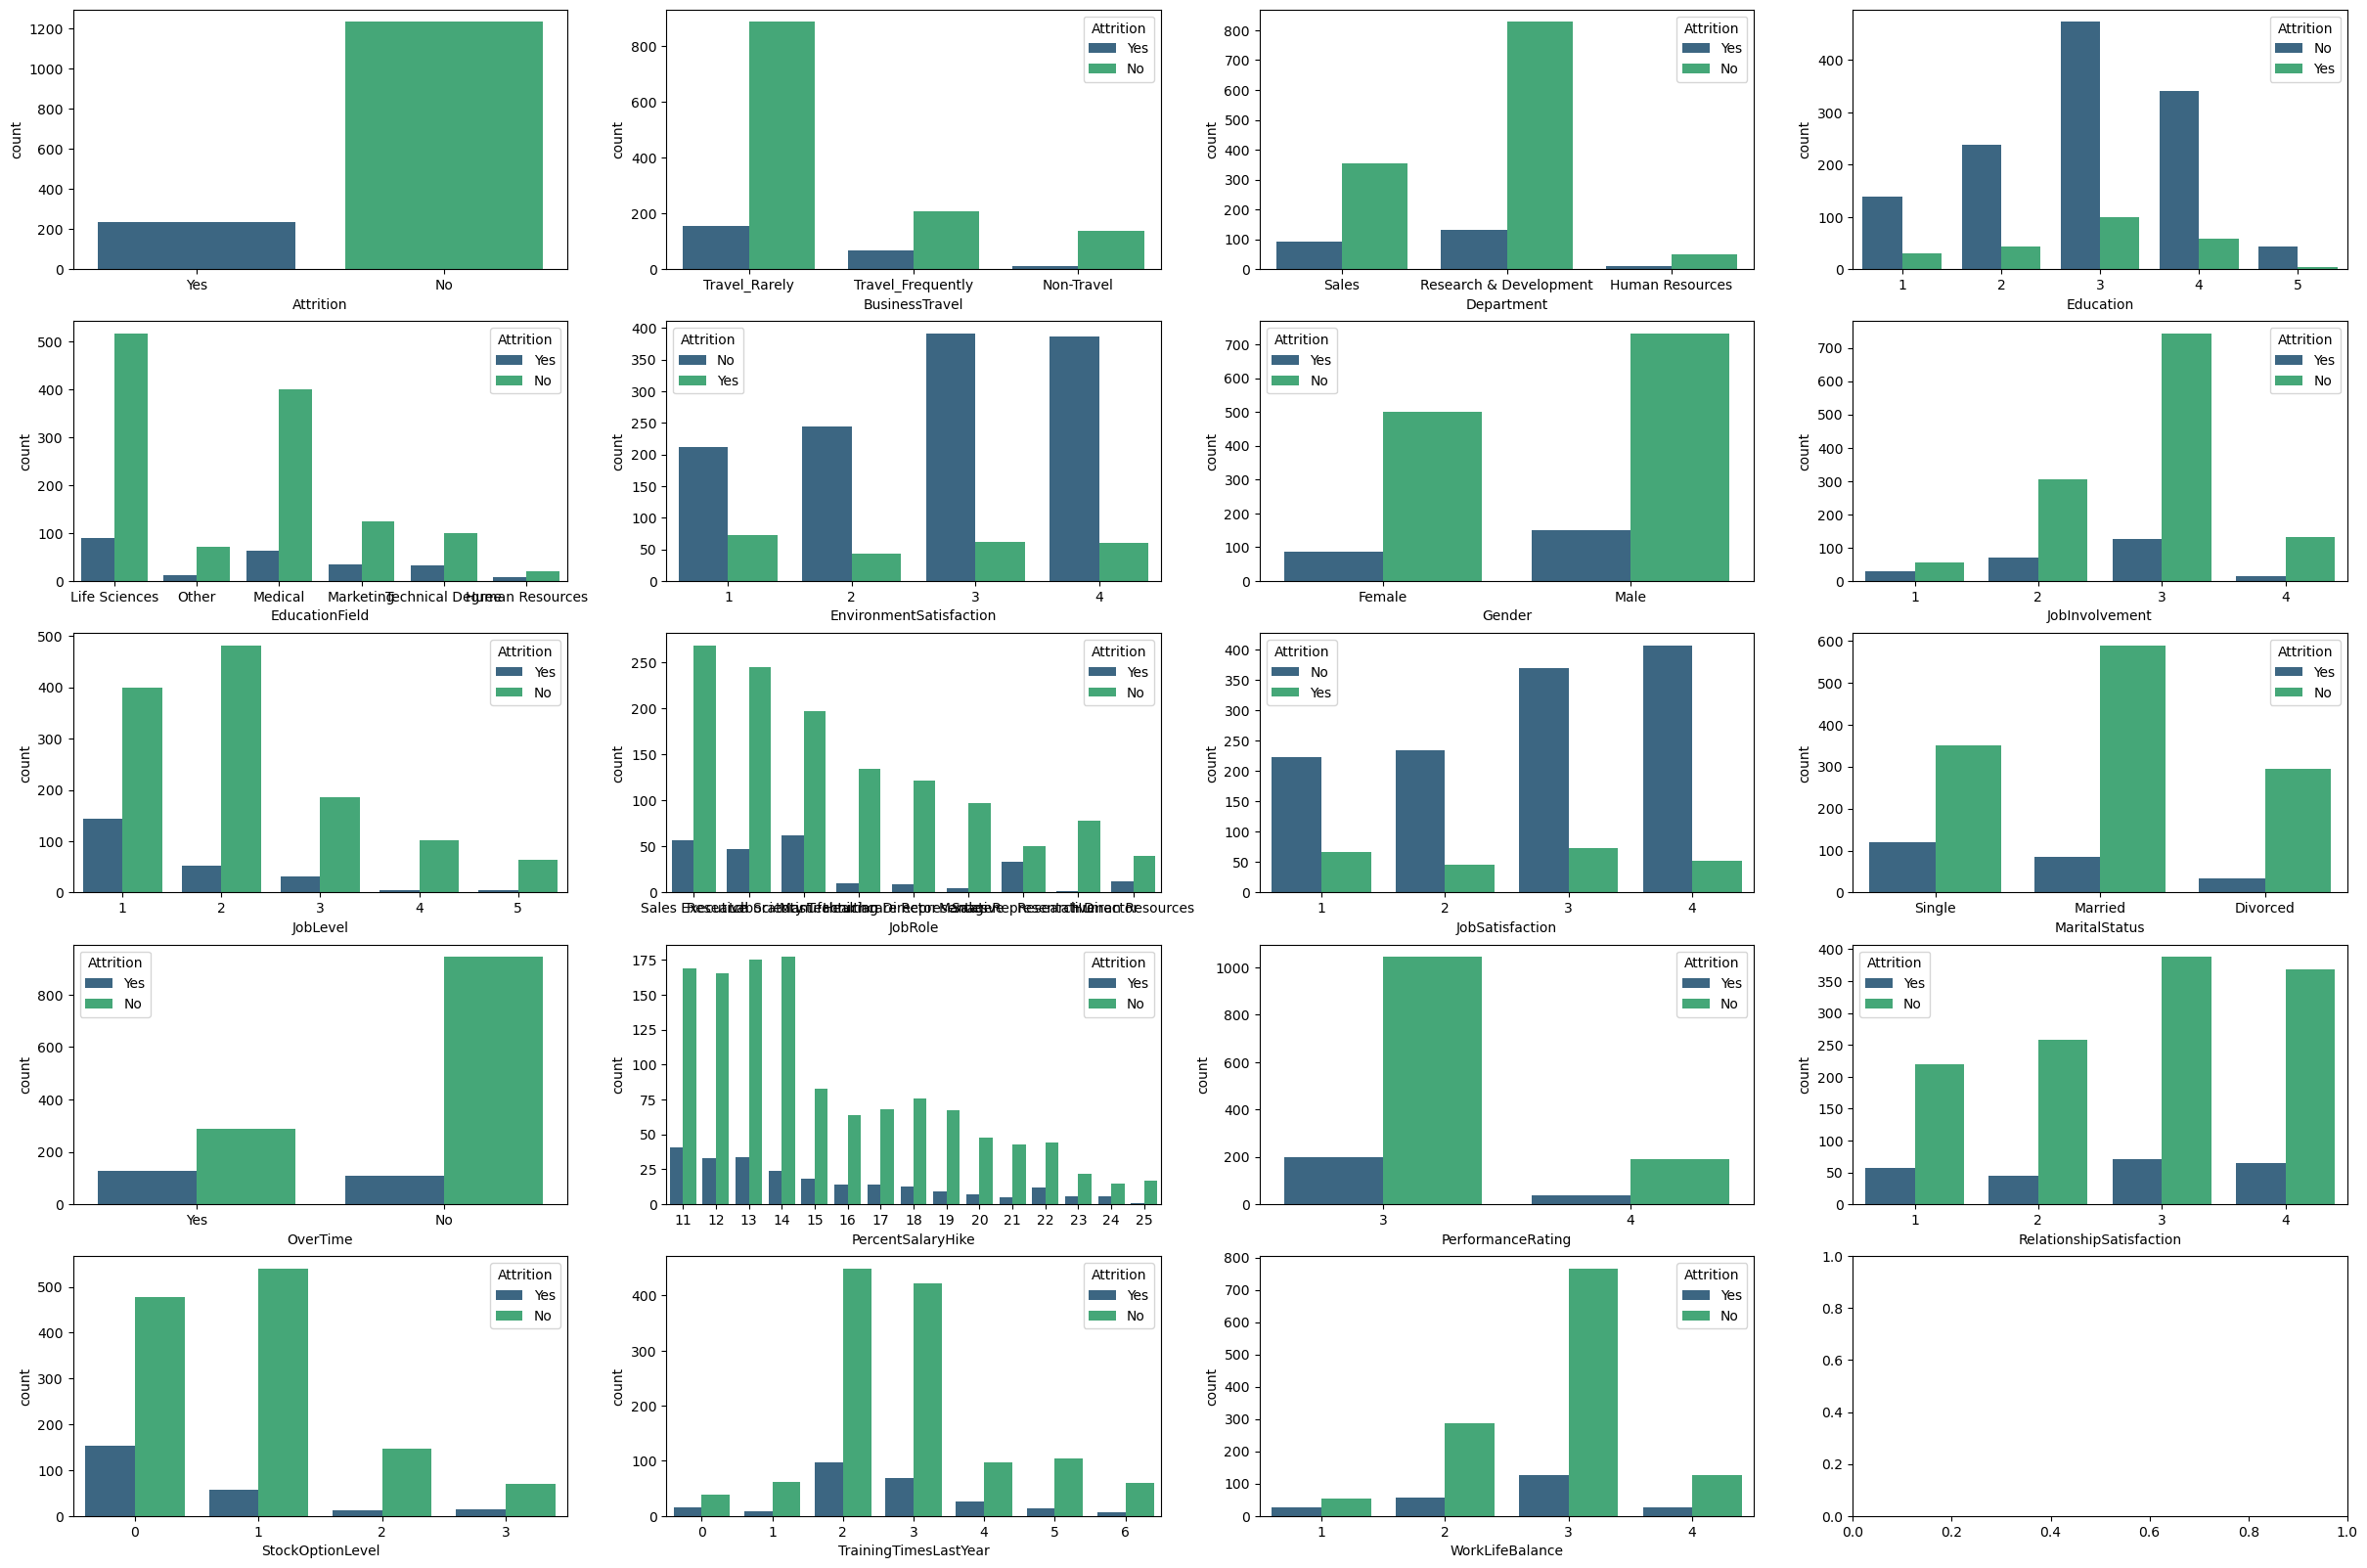

In [20]:

fig, axes = plt.subplots(ncols = 4, nrows =5, figsize =(30,20))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.countplot(x = col, data = df, ax = axes[i], hue = 'Attrition', palette = 'viridis')

<Axes: xlabel='JobRole', ylabel='count'>

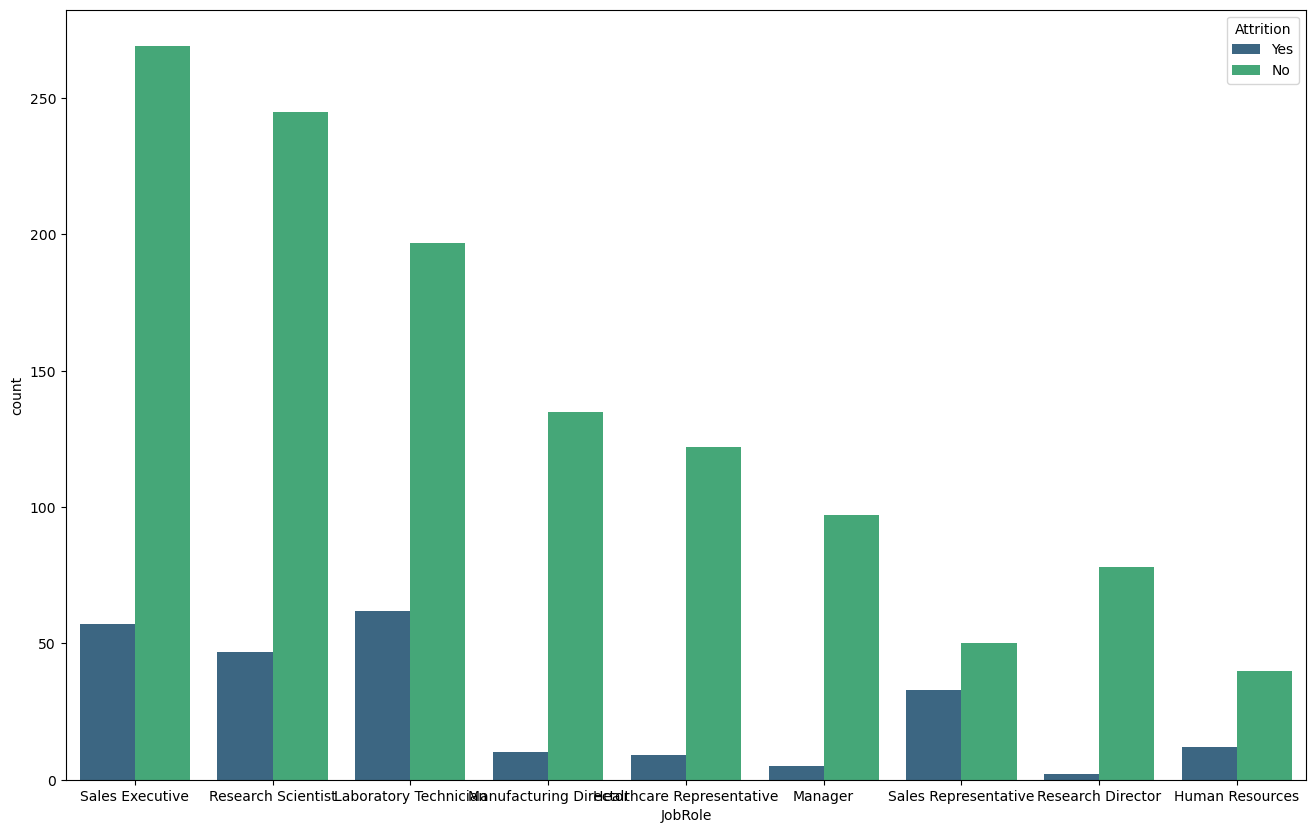

In [21]:
plt.figure(figsize=(16,10))
sns.countplot(x ='JobRole', data = df, hue = 'Attrition', palette = 'viridis')

#### Observation
- Most employees stayed with the company, while a smaller number left.
- Employees who worked **overtime** seem to have higher attrition than those who did not.
- Attrition also appears higher among employees with lower **job levels** and lower **job satisfaction**.
- **Single employees** and employees with no **stock options** also show relatively more attrition.
- Employees who **travel frequently** appear to have higher attrition than those who travel rarely or do not travel.
- Sales Representatives and Laboratory Technicians appear to have a relatively high proportion of employees leaving compapred to the remaining **jobroles**.
- Some variables, such as PerformanceRating and PercentSalaryHike, do not show a clear difference in attrition from the chart.

These are only initial observations because the chart shows counts. I will calculate the attrition rate for each group to compare them properly.

### Attrition Rate Across Categorical Employee Characteristics

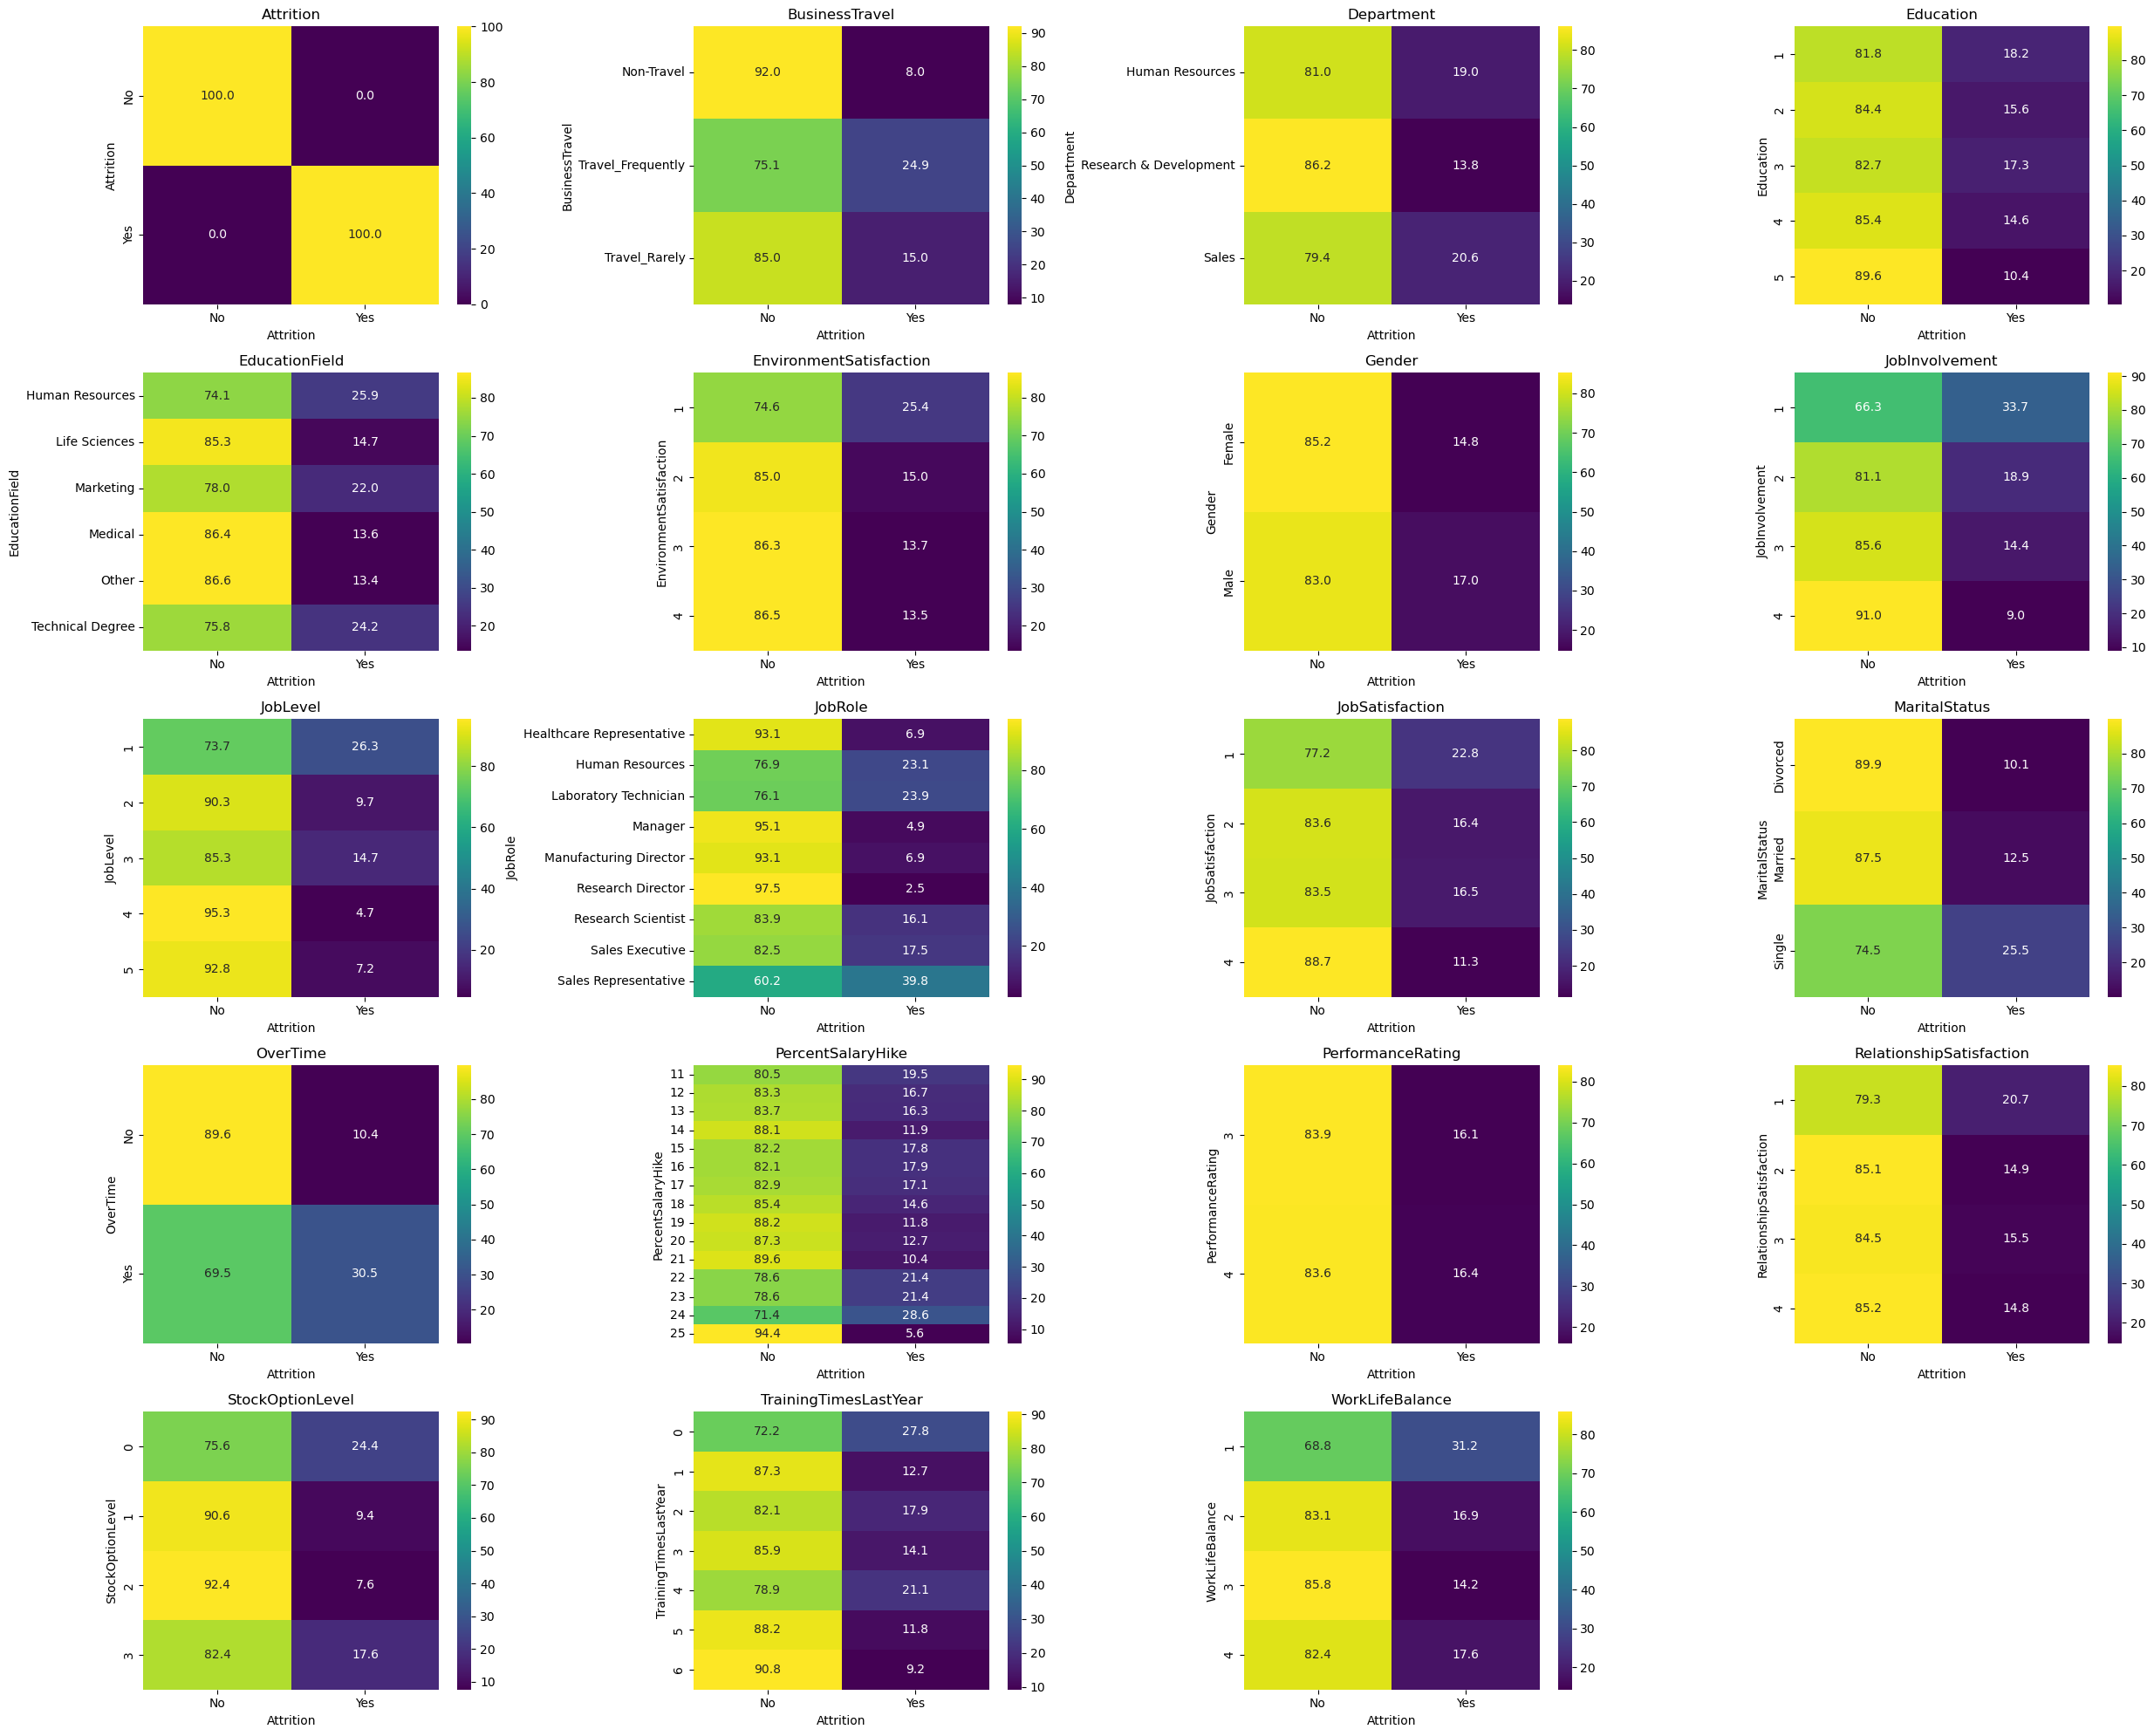

In [22]:
fig, axes = plt.subplots(nrows=5, ncols=4, figsize=(25, 20))
axes = axes.flatten()

for i, col in enumerate(cat_cols):

    ct = pd.crosstab(
        df[col],
        df['Attrition'],
        normalize='index'
    ) * 100

    sns.heatmap(
        ct,
        annot=True,
        fmt=".1f",
        cmap="viridis",
        ax=axes[i]
    )

    axes[i].set_title(col)
    axes[i].set_xlabel("Attrition")
    axes[i].set_ylabel(col)

# Remove empty axes if you have fewer than 20 categorical columns
for j in range(len(cat_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

#### Observation

- Attrition varies across several categories, with some groups showing noticeably higher attrition rates than others.
- Employees who work **overtime** have a much higher attrition rate (30.5%) than those who do not (10.4%).
- Employees with lower **job involvement** have higher attrition. Attrition is highest at JobInvolvement level 1 (33.7%) and lowest at level 4 (9.0%).
- Lower **job levels** also show higher attrition. JobLevel 1 has an attrition rate of 26.3%, compared with 4.7% at level 4.
- Employees with lower **environment satisfaction**, **relationship satisfaction** and **job satisfaction** generally have higher attrition rates.
- **Single employees** have a higher attrition rate (25.5%) compared with married (12.5%) and divorced employees (10.1%).
- Employees with no **stock options** have a relatively high attrition rate (24.4%), while levels 1 and 2 have much lower rates.
- Employees who **travel frequently** have higher attrition (24.9%) than those who travel rarely (15.0%) or do not travel (8.0%).
- Attrition also varies across **job roles**. Sales Representatives have the highest attrition rate (39.8%), followed by Laboratory Technicians (23.9%) and Human Resources (23.1%).
- Employees with low **work-life balance** have higher attrition. The rate is 31.2% at level 1 compared with 14.2% at level 3.

Overtime, job involvement, job level, job role, marital status, stock options, satisfaction levels, and work-life balance stand out as variables that should be investigated further.

### Distribution of Numerical variables

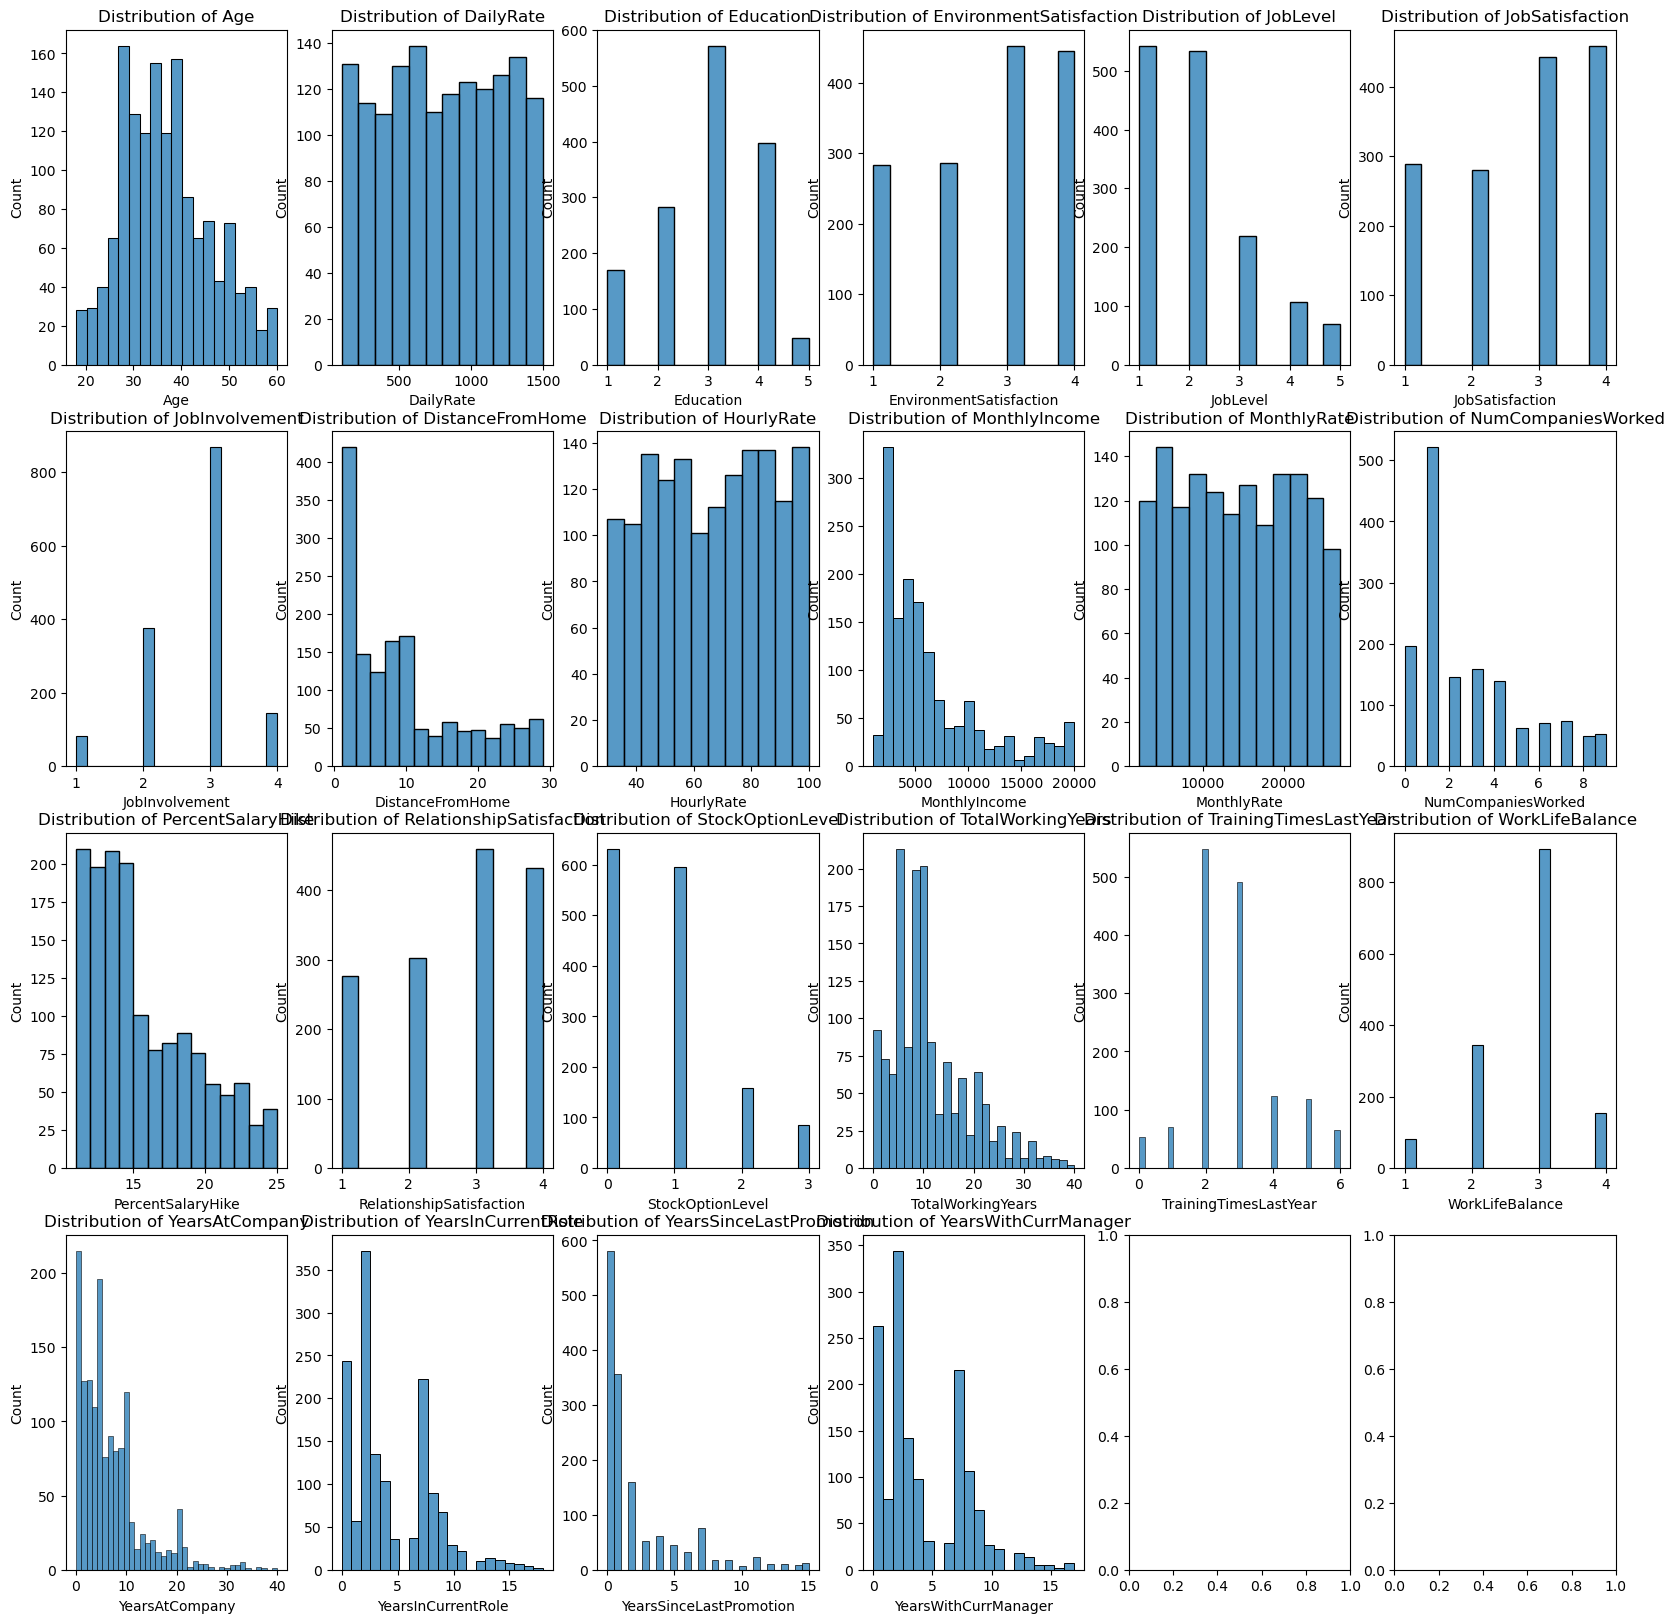

In [23]:
fig, axes = plt.subplots(ncols = 6, nrows =4, figsize =(20,20))
axes = axes.flatten()

for i, col in enumerate(numeric):
    sns.histplot(x=col,data = df, ax = axes[i], palette= 'viridis')
    axes[i].set_title(f'Distribution of {col}')
    

#### Observation

- Age is mostly concentrated around the 30–40 range, with fewer employees at the younger ages, giving the distribution a slight right skew.
- DailyRate, HourlyRate, and Monthly rate appear fairly spread out across their ranges without a strong skew.
- DistanceFromHome is right-skewed, with most employees living relatively close to work and fewer employees living much farther away.
- MonthlyIncome is strongly right-skewed, with most employees earning lower to middle incomes and fewer employees having very high incomes.
- NumCompaniesWorked is right-skewed, as most employees have worked for few companies while fewer employees have worked for many companies.
- PercentSalaryHike is concentrated around the lower values and has a right-skewed distribution.
- TotalWorkingYears is right-skewed, with most employees having fewer years of experience and fewer employees having very long careers.
- YearsAtCompany, YearsInCurrentRole, YearsSinceLastPromotion and YearsWithCurrManager are also right-skewed, with most employees having relatively fewer years in these positions and fewer employees having much longer tenures.
- TrainingTimesLastYear is concentrated around 2–3 training sessions, with fewer employees at the extreme values.
- The ordinal variables such as Education, JobLevel, JobSatisfaction, JobInvolvement, EnvironmentSatisfaction, RelationshipSatisfaction, StockOptionLevel and WorkLifeBalance are concentrated around particular levels rather than being normally distributed.

### Distribution of Numerical variables by Attrition

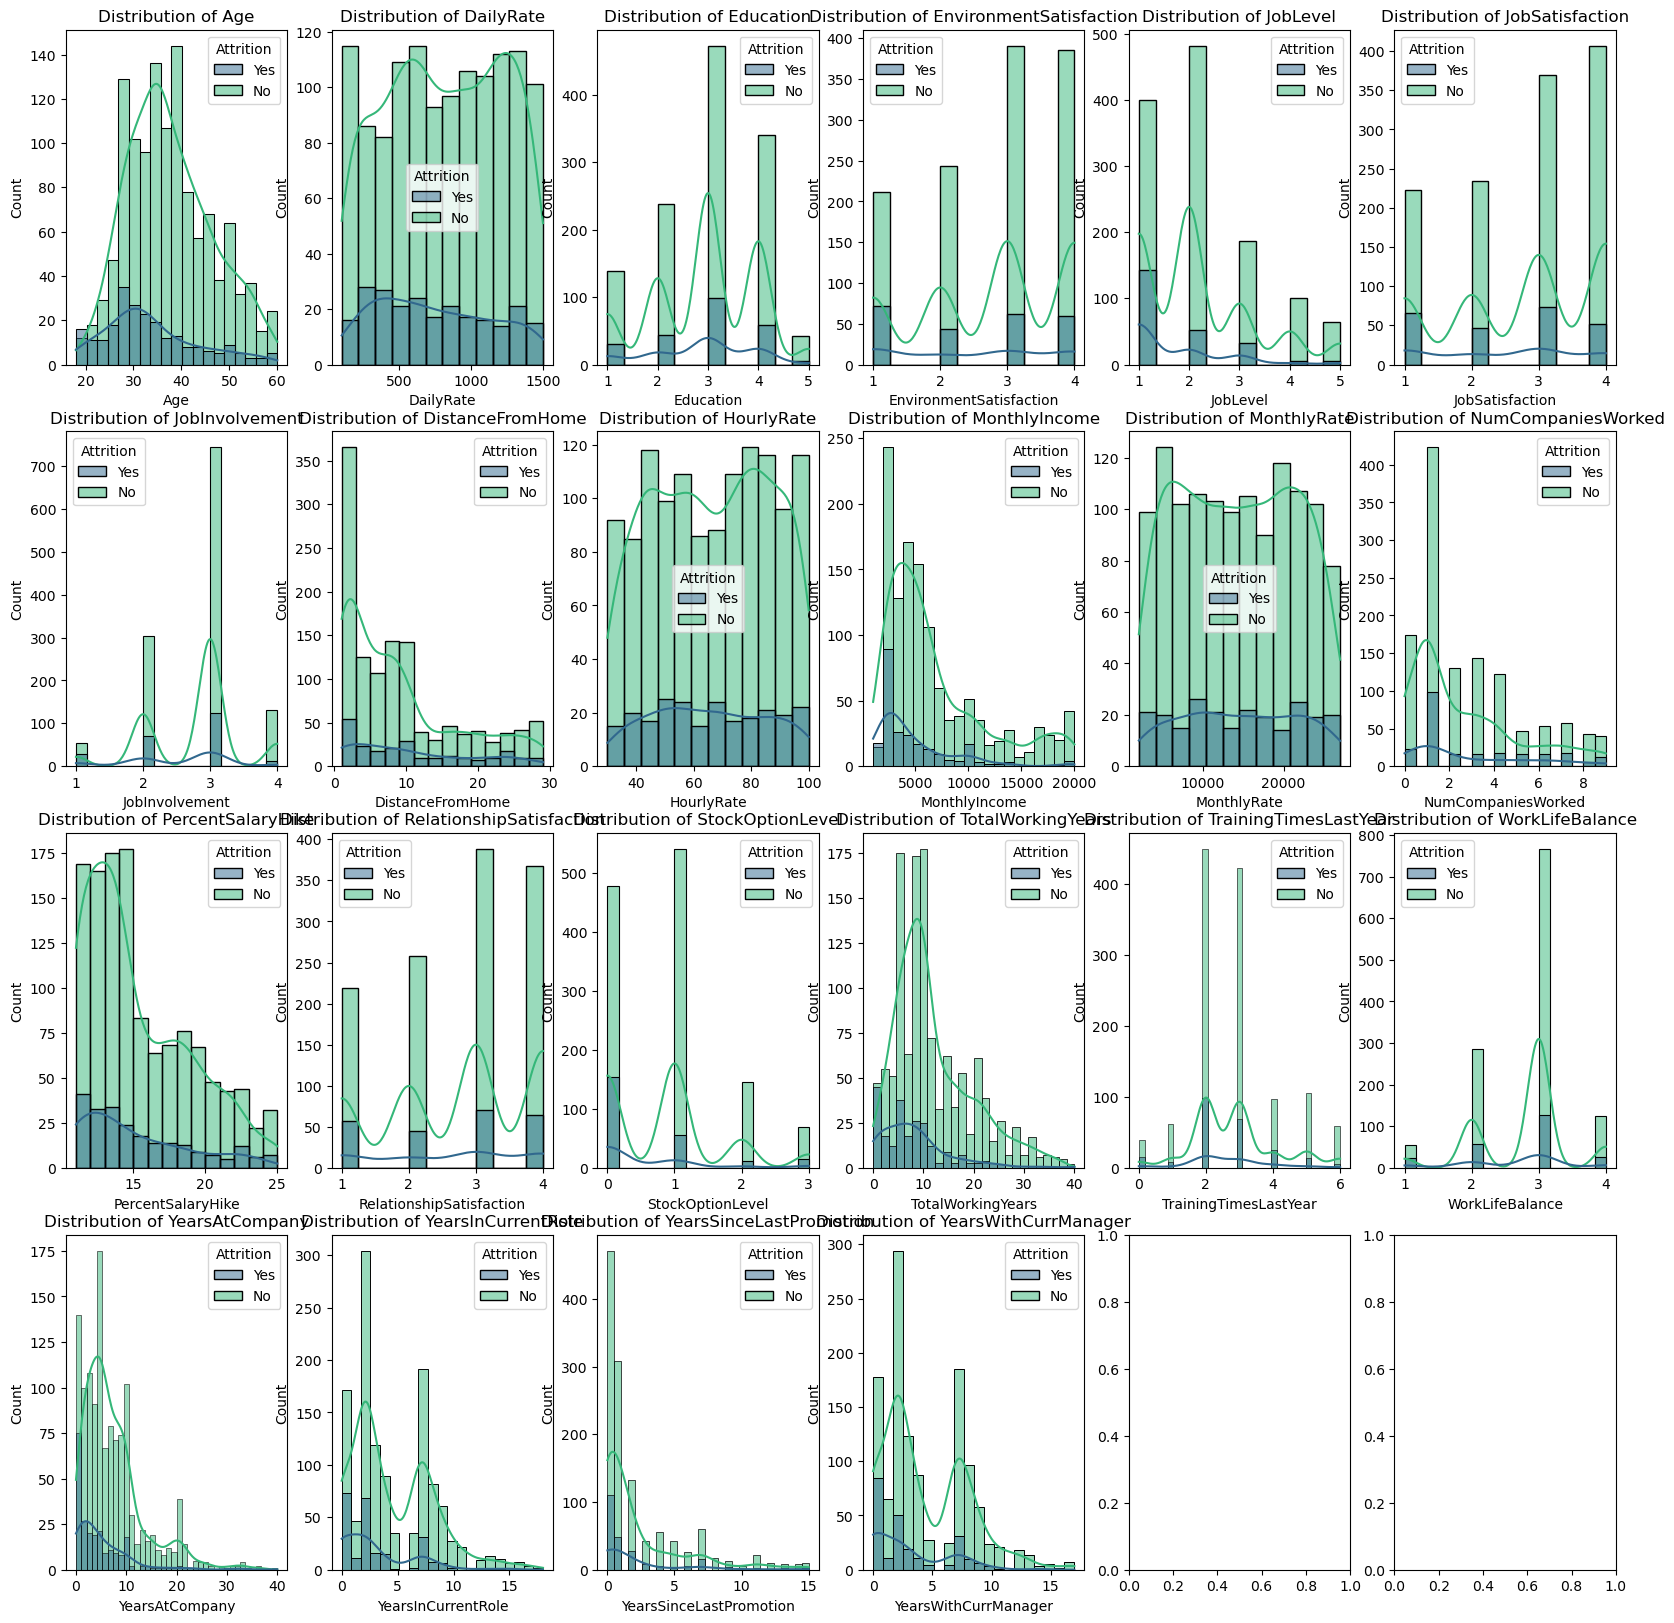

In [24]:
fig, axes = plt.subplots(ncols = 6, nrows =4, figsize =(20,20))
axes = axes.flatten()

for i, col in enumerate(numeric):
    sns.histplot(x=col, hue = 'Attrition', kde = True, data = df, ax = axes[i], palette= 'viridis')
    axes[i].set_title(f'Distribution of {col}')

#### Observation

- The age distribution shows that employees who left tend to be concentrated at younger ages, while employees who stayed are spread across a wider age range. This suggests that younger employees may have higher attrition.
- MonthlyIncome is strongly right-skewed. Employees who left are more concentrated at the lower income levels, while employees who stayed are more spread across the higher income range. This suggests that lower-paid employees may be more likely to leave.
- TotalWorkingYears is right-skewed. Employees who left are more concentrated among those with fewer total years of experience, while employees who stayed are more spread towards higher experience levels.
- YearsAtCompany is strongly right-skewed. Employees who left are concentrated at lower years of service, while employees who stayed are more widely distributed and include employees with longer tenure.
- YearsInCurrentRole shows a similar pattern. Employees who left are mostly concentrated at lower numbers of years in their current role, while employees who stayed are more represented at higher values.
- YearsWithCurrManager follows a similar pattern, with employees who left concentrated at lower values while employees who stayed are more spread across longer periods with their current manager.
- JobInvolvement, JobLevel, JobSatisfaction and EnvironmentSatisfaction show differences between the two groups. Employees who left appear more concentrated in the lower levels, while employees who stayed are more concentrated in the higher levels.
- StockOptionLevel shows a noticeable difference. Employees who left are particularly concentrated at level 0, while employees who stayed are more distributed across the higher levels.
- WorkLifeBalance shows a higher concentration of employees who left at the lower levels, particularly level 1, while employees who stayed are mainly concentrated around level 3.

The numerical distributions suggest that employees who left tend to be younger, have lower income, fewer total working years and shorter tenure in the company and their current roles. The categorical/ordinal variables also suggest higher attrition among employees with lower job involvement, lower job satisfaction, lower environment satisfaction, lower job levels, no stock options and poorer work-life balance.

These are initial observations from the distributions. The differences should be quantified using summary statistics and attrition rates before drawing conclusions about the strongest factors associated with attrition.

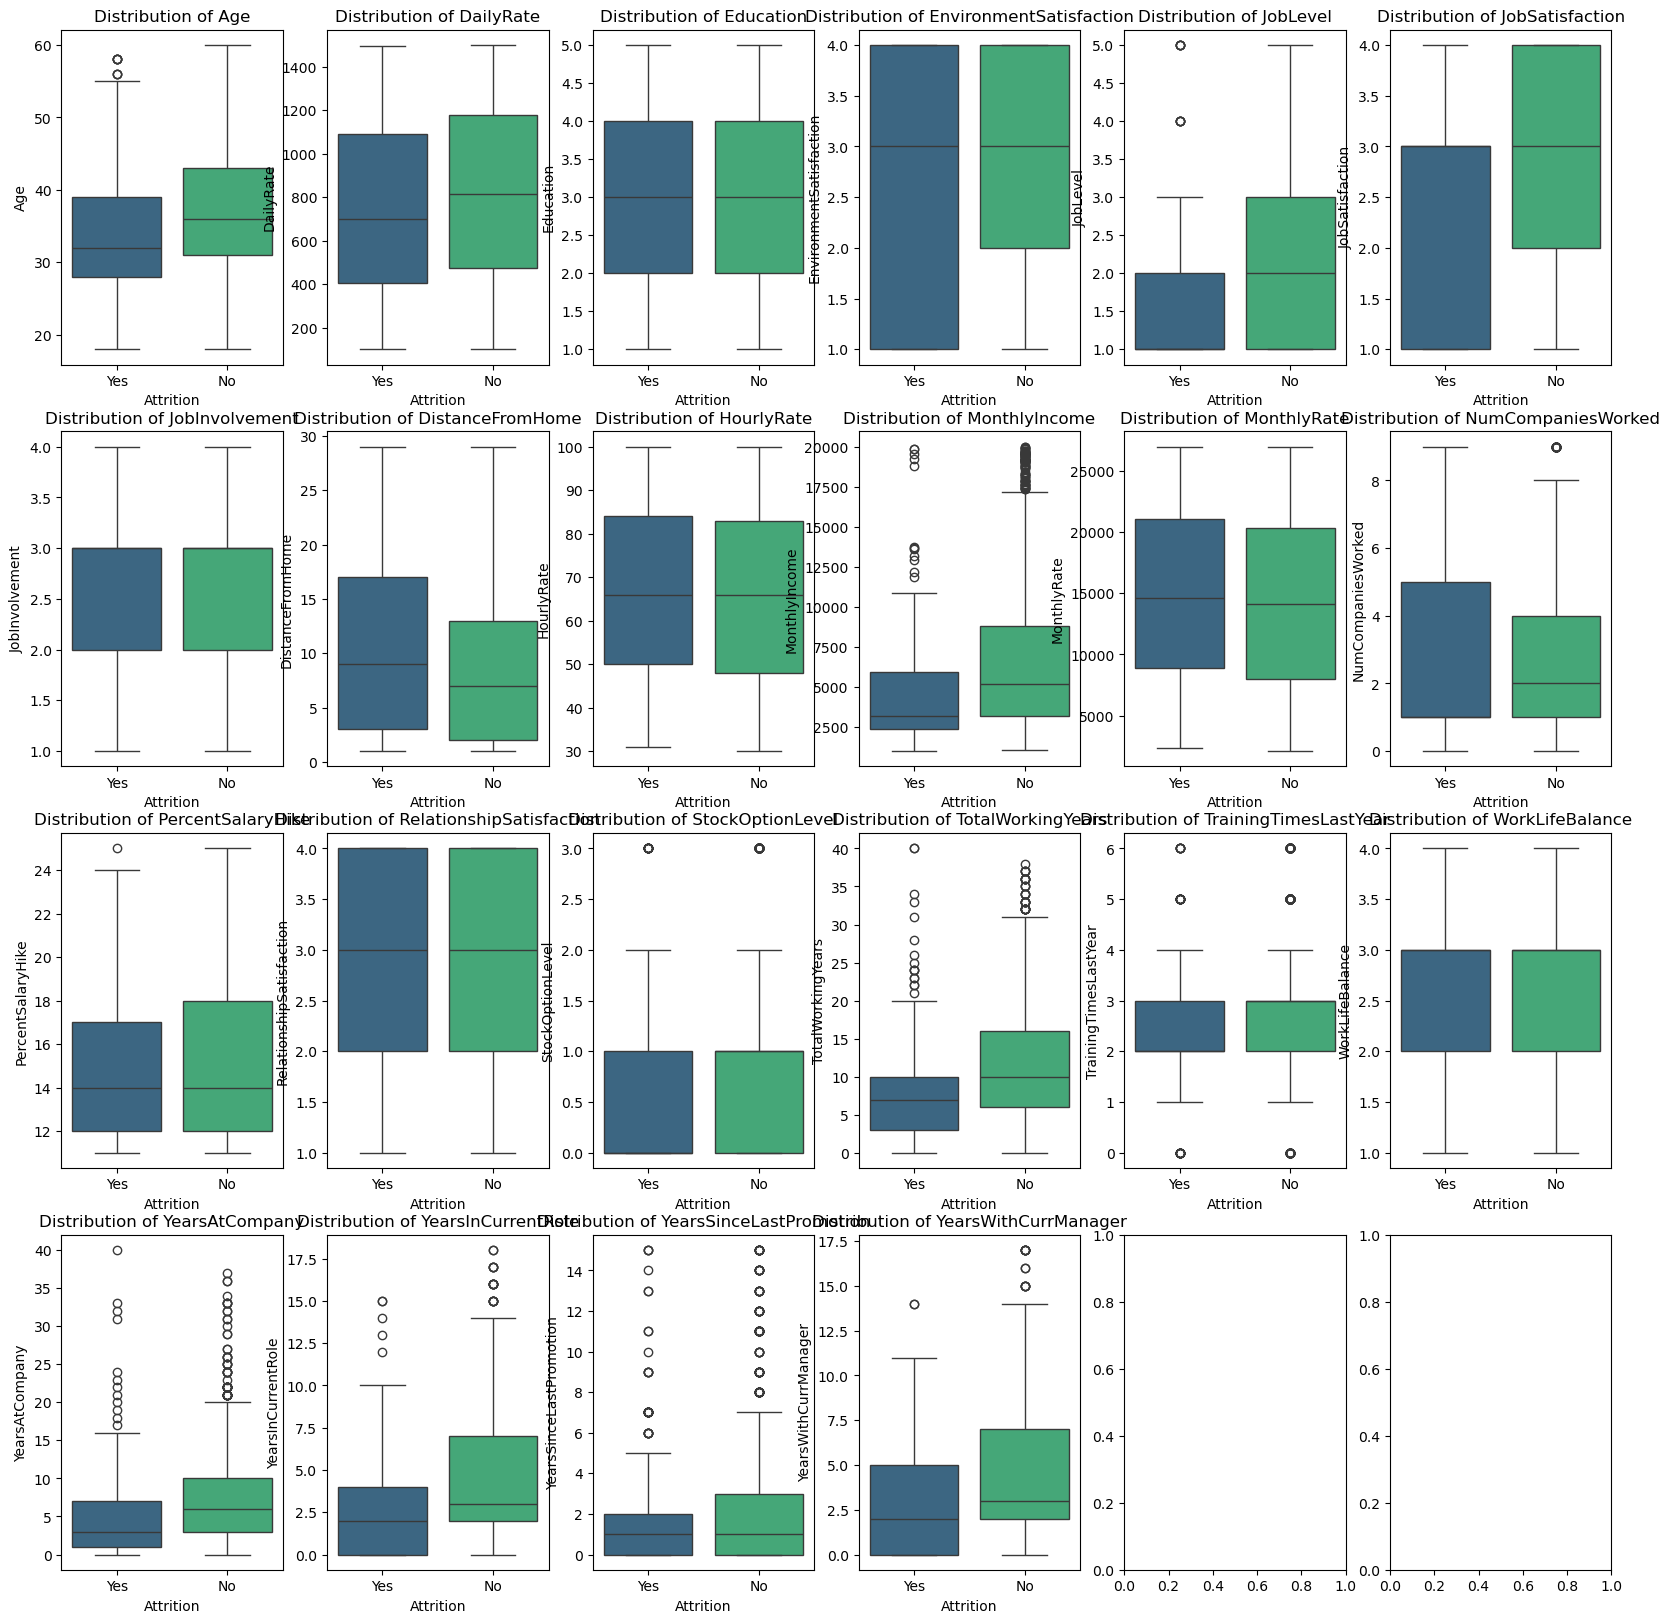

In [25]:
cat_cols = [ 'Attrition', 'BusinessTravel', 'Department', 'Education','EducationField','EnvironmentSatisfaction','Gender','JobInvolvement','JobLevel', 'JobRole', 'JobSatisfaction','MaritalStatus', 'OverTime', 'PercentSalaryHike','PerformanceRating','RelationshipSatisfaction','StockOptionLevel','TrainingTimesLastYear', 'WorkLifeBalance']


numeric_cols = ['Age', 'DailyRate', 'DistanceFromHome', 'HourlyRate', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked','TotalWorkingYears','YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion','YearsWithCurrManager']
fig, axes = plt.subplots(ncols = 6, nrows =4, figsize =(20,20))
axes = axes.flatten()

for i, col in enumerate(numeric):
    sns.boxplot(y=col, x= 'Attrition', data = df, ax = axes[i], palette= 'viridis')
    axes[i].set_title(f'Distribution of {col}')

#### Observation

- Employees who left tend to be younger than those who stayed, with a lower median age.
- Employees who left generally have lower MonthlyIncome, JobLevel and TotalWorkingYears.
- Employees who left also tend to have shorter tenure, including fewer YearsAtCompany, YearsInCurrentRole and YearsWithCurrManager.
- Lower EnvironmentSatisfaction and JobSatisfaction are more common among employees who left.
- Employees who left appear to live slightly farther from work than those who stayed.
- DailyRate, HourlyRate, MonthlyRate, PercentSalaryHike, RelationshipSatisfaction and TrainingTimesLastYear show little difference between the two groups.
- Several numerical variables, particularly MonthlyIncome, TotalWorkingYears and the tenure-related variables, contain outliers and are right-skewed.

The boxplots suggest that age, income, job level, satisfaction, experience and tenure may be related to attrition. These differences will be investigated further.

### Correlation Between Numerical Employee Characteristics

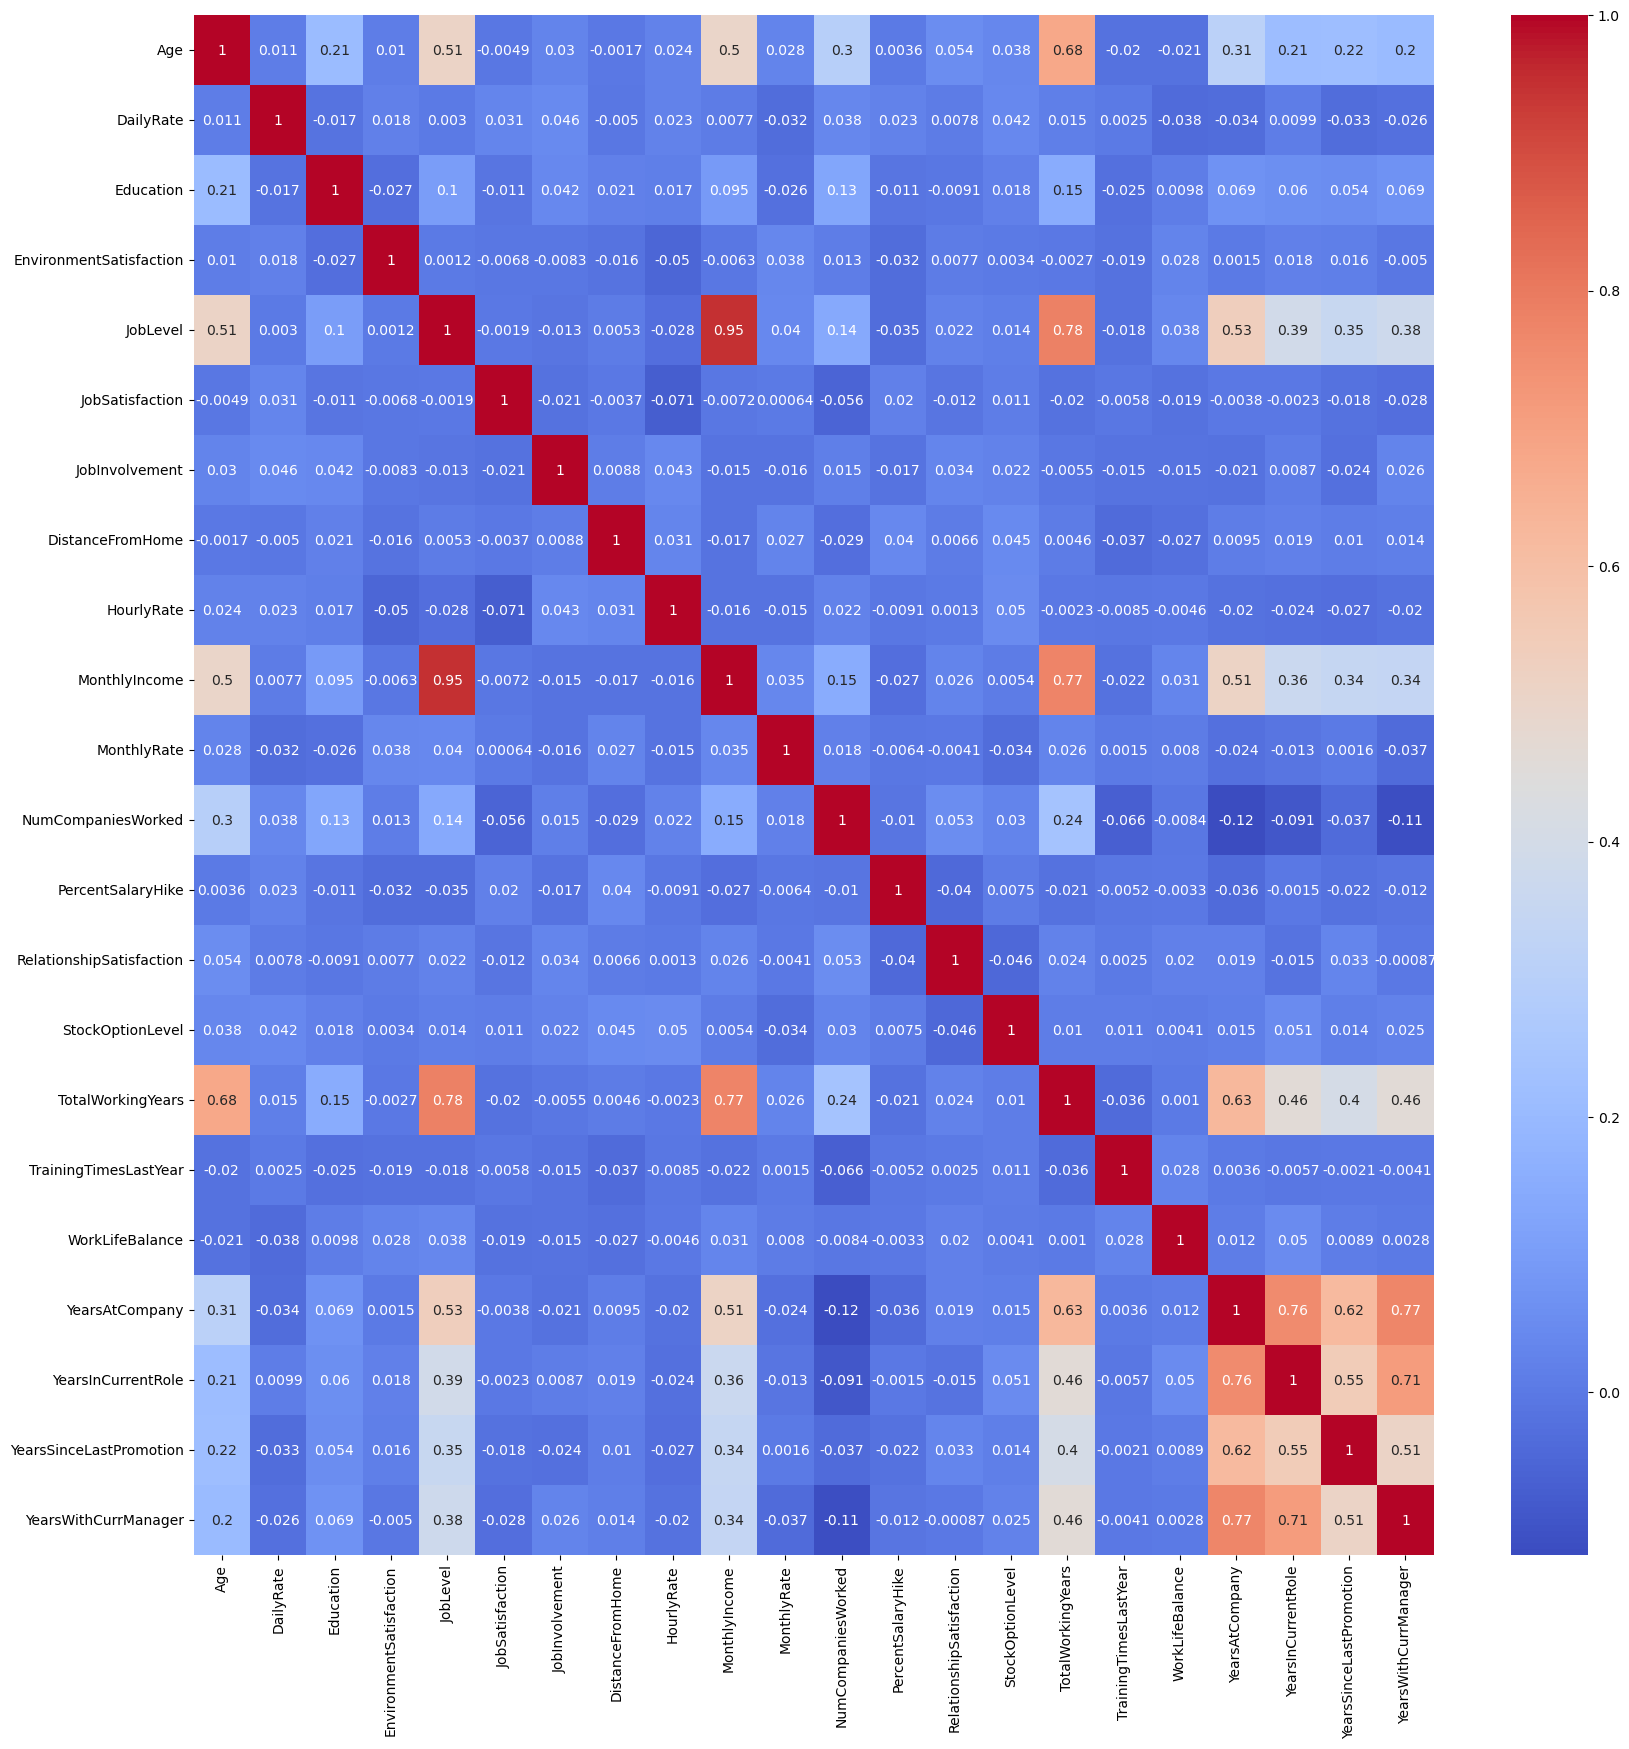

<Figure size 640x480 with 0 Axes>

In [26]:
corr=df[numeric].corr()
plt.figure(figsize=(20, 20)) 
sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)
plt.show()
plt.savefig('corr.png')

#### Observation

- Most variables have weak correlations with each other, suggesting that there are no strong linear relationships between most of the numerical variables.
- JobLevel and MonthlyIncome have a very strong positive correlation (0.95). This suggests that employees at higher job levels generally have higher monthly incomes.
- MonthlyIncome is also strongly related to TotalWorkingYears (0.77), while JobLevel and TotalWorkingYears have a strong positive relationship (0.78).
- YearsAtCompany is strongly related to YearsWithCurrManager (0.77) and YearsInCurrentRole (0.76). This is expected since employees who have spent more years in the company are likely to have spent more time in their current role or with their current manager.
- TotalWorkingYears and YearsAtCompany also have a relatively strong positive correlation (0.63).
- Attrition is not shown in this correlation heatmap because it is a categorical variable. Its relationship with individual variables will be examined separately using comparisons and crosstabs.

### Overtime-Related Attrition by Work-Life Balance

In [27]:
pd.crosstab(
    [df['WorkLifeBalance'], df['OverTime']],
    df['Attrition'],
    normalize='index'
) * 100

Attrition                        No        Yes
WorkLifeBalance OverTime                      
1               No        74.137931  25.862069
                Yes       54.545455  45.454545
2               No        89.166667  10.833333
                Yes       69.230769  30.769231
3               No        91.549296   8.450704
                Yes       71.259843  28.740157
4               No        87.179487  12.820513
                Yes       66.666667  33.333333

#### Observation

- Employees who work overtime have higher attrition across all work-life balance levels.
- The highest attrition is among employees with poor work-life balance who work overtime (45.5%).

### Overtime-Related Attrition across Job Roles

In [28]:
pd.crosstab(
    [df['JobRole'], df['OverTime']],
    df['Attrition'],
    normalize='index'
) * 100

Attrition                                  No        Yes
JobRole                   OverTime                      
Healthcare Representative No        92.553191   7.446809
                          Yes       94.594595   5.405405
Human Resources           No        82.051282  17.948718
                          Yes       61.538462  38.461538
Laboratory Technician     No        84.263959  15.736041
                          Yes       50.000000  50.000000
Manager                   No        98.666667   1.333333
                          Yes       85.185185  14.814815
Manufacturing Director    No        94.339623   5.660377
                          Yes       89.743590  10.256410
Research Director         No        98.245614   1.754386
                          Yes       95.652174   4.347826
Research Scientist        No        92.820513   7.179487
                          Yes       65.979381  34.020619
Sales Executive           No        88.793103  11.206897
                          Yes       67.021277  32.978723
Sales Representative      No        71.186441  28.813559
                          Yes       33.333333  66.666667

#### Observation

- Attrition is generally higher among employees who work overtime in several job roles.
- Sales Representatives who work overtime have the highest attrition rate (66.7%), followed by Laboratory Technicians (50.0%).
- This suggests that overtime may be particularly associated with attrition in some job roles.

### Overtime-Related Attrition Across Environment Satisfaction Levels

In [29]:
pd.crosstab(
    [df['EnvironmentSatisfaction'], df['OverTime']],
    df['Attrition'],
    normalize='index'
) * 100

Attrition                                No        Yes
EnvironmentSatisfaction OverTime                      
1                       No        81.981982  18.018018
                        Yes       48.387097  51.612903
2                       No        92.233010   7.766990
                        Yes       66.666667  33.333333
3                       No        90.000000  10.000000
                        Yes       77.443609  22.556391
4                       No        92.810458   7.189542
                        Yes       72.857143  27.142857

#### Observation

- Employees who work overtime have higher attrition across all levels of environment satisfaction.
- The highest attrition is among employees with the lowest environment satisfaction who work overtime (51.6%).
- This suggests that overtime may be particularly problematic for employees who are already dissatisfied with their work environment.

### Overtime-Related Attrition Across Job Involvement Levels

In [30]:
pd.crosstab(
    [df['JobInvolvement'], df['OverTime']],
    df['Attrition'],
    normalize='index'
) * 100

Attrition                       No        Yes
JobInvolvement OverTime                      
1              No        74.137931  25.862069
               Yes       48.000000  52.000000
2              No        87.777778  12.222222
               Yes       63.809524  36.190476
3              No        91.011236   8.988764
               Yes       71.836735  28.163265
4              No        94.174757   5.825243
               Yes       82.926829  17.073171

#### Observation

- Employees who work overtime have higher attrition across all levels of job involvement.
- The highest attrition is among employees with low job involvement who work overtime (52.0%).
- This suggests that overtime may be particularly associated with attrition among employees with lower job involvement.

### Overtime-Related Attrition by Job Level

In [31]:
pd.crosstab(
    [df['JobLevel'], df['OverTime']],
    df['Attrition'],
    normalize='index'
) * 100

Attrition                 No        Yes
JobLevel OverTime                      
1        No        84.237726  15.762274
         Yes       47.435897  52.564103
2        No        93.298969   6.701031
         Yes       82.191781  17.808219
3        No        87.741935  12.258065
         Yes       79.365079  20.634921
4        No        97.260274   2.739726
         Yes       90.909091   9.090909
5        No        96.078431   3.921569
         Yes       83.333333  16.666667

#### Observation

- Employees who work overtime have higher attrition across all job levels.
- The largest difference is among JobLevel 1 employees, where attrition increases from 15.8% without overtime to 52.6% with overtime.
- This suggests that overtime may be particularly associated with attrition among lower-level employees.

### Attrition by Job Satisfaction and Business Travel

In [32]:
pd.crosstab(
    [df['JobSatisfaction'], df['BusinessTravel']],
    df['Attrition'],
    normalize='index'
) * 100

Attrition                                 No        Yes
JobSatisfaction BusinessTravel                         
1               Non-Travel         73.913043  26.086957
                Travel_Frequently  68.627451  31.372549
                Travel_Rarely      79.534884  20.465116
2               Non-Travel         89.655172  10.344828
                Travel_Frequently  75.510204  24.489796
                Travel_Rarely      84.653465  15.346535
3               Non-Travel         96.296296   3.703704
                Travel_Frequently  70.238095  29.761905
                Travel_Rarely      84.868421  15.131579
4               Non-Travel         97.727273   2.272727
                Travel_Frequently  82.795699  17.204301
                Travel_Rarely      89.130435  10.869565

#### Observation
* Attrition generally decreases as job satisfaction increases. However, employees who travel frequently consistently show higher attrition rates across all satisfaction levels. 
* The highest attrition rate (31.4%) is observed among employees with low job satisfaction who travel frequently, while even highly satisfied frequent travellers have a relatively higher attrition rate (17.2%) compared with non-travellers (2.3%).
* This suggests that frequent business travel is associated with higher attrition, even among employees with higher job satisfaction.

### Attrition Across Job Satisfaction and Work-Life Balance Levels

In [33]:
pd.crosstab(
    [df['JobSatisfaction'], df['WorkLifeBalance']],
    df['Attrition'],
    normalize='index'
) * 100

Attrition                               No        Yes
JobSatisfaction WorkLifeBalance                      
1               1                52.941176  47.058824
                2                78.688525  21.311475
                3                78.571429  21.428571
                4                79.310345  20.689655
2               1                77.777778  22.222222
                2                86.206897  13.793103
                3                85.142857  14.857143
                4                72.413793  27.586207
3               1                61.904762  38.095238
                2                82.178218  17.821782
                3                84.249084  15.750916
                4                91.489362   8.510638
4               1                79.166667  20.833333
                2                84.677419  15.322581
                3                92.775665   7.224335
                4                81.250000  18.750000

#### Observation

- Employees with the lowest job satisfaction and poorest work-life balance have the highest attrition (47.1%).
- The combination of low job satisfaction and poor work-life balance appears to be associated with higher attrition, although the pattern is not consistent across all groups.

### Attrition Across Job Involvement and Work-Life Balance Levels

In [34]:
pd.crosstab(
    [df['JobInvolvement'], df['WorkLifeBalance']],
    df['Attrition'],
    normalize='index'
) * 100

Attrition                               No        Yes
JobInvolvement WorkLifeBalance                       
1              1                 25.000000  75.000000
               2                 55.000000  45.000000
               3                 71.698113  28.301887
               4                 83.333333  16.666667
2              1                 63.157895  36.842105
               2                 80.487805  19.512195
               3                 83.690987  16.309013
               4                 75.609756  24.390244
3              1                 70.588235  29.411765
               2                 85.365854  14.634146
               3                 87.596899  12.403101
               4                 83.333333  16.666667
4              1                100.000000   0.000000
               2                 91.891892   8.108108
               3                 89.010989  10.989011
               4                100.000000   0.000000

#### Observation

- Employees with low job involvement and poor work-life balance show particularly high attrition.
- The highest attrition is among employees with the lowest job involvement and poorest work-life balance (75%).
- The pattern is less consistent at higher levels of job involvement.

### Overtime-Related Attrition Across Age Groups

In [35]:
df['Age'].value_counts().sort_index()

Age
18     8
19     9
20    11
21    13
22    16
23    14
24    26
25    26
26    39
27    48
28    48
29    68
30    60
31    69
32    61
33    58
34    77
35    78
36    69
37    50
38    58
39    42
40    57
41    40
42    46
43    32
44    33
45    41
46    33
47    24
48    19
49    24
50    30
51    19
52    18
53    19
54    18
55    22
56    14
57     4
58    14
59    10
60     5
Name: count, dtype: int64

In [36]:
### Creating AgeGroup to group employee ages into groups

bin = [17,25,35,45,55,100]
labels = ['18-25','26-35','36-45','46-55','55+']

df['AgeGroup'] = pd.cut(
    df['Age'],
    bins = bin,
    labels= labels
)

In [37]:
df['AgeGroup'].value_counts(normalize=True)*100.

AgeGroup
26-35    41.224490
36-45    31.836735
46-55    15.374150
18-25     8.367347
55+       3.197279
Name: proportion, dtype: float64

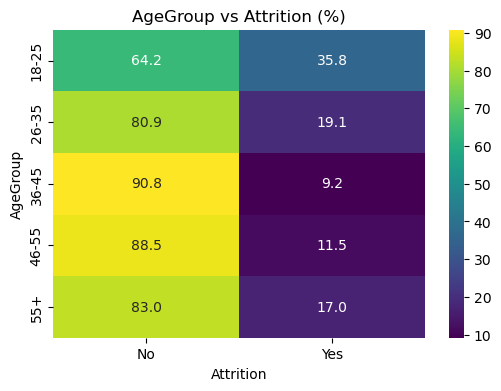

In [38]:
ct = pd.crosstab(

    df['AgeGroup'],

    df['Attrition'],

    normalize='index'

) * 100


plt.figure(figsize=(6,4))

sns.heatmap(ct, annot=True, fmt='.1f', cmap='viridis')

plt.title('AgeGroup vs Attrition (%)')

plt.ylabel('AgeGroup')

plt.xlabel('Attrition')

plt.show()

#### Observation
 **Attrition varies considerably across age groups, with the highest attrition among employees aged 18–25 (35.8%). Attrition is lowest among employees aged 36–45 (9.2%), suggesting that younger employees may be more likely to leave the company.**

In [39]:
pd.crosstab(
    [df['AgeGroup'], df['OverTime']],
    df['Attrition'],
    normalize='index'
) * 100

Attrition                 No        Yes
AgeGroup OverTime                      
18-25    No        77.380952  22.619048
         Yes       35.897436  64.102564
26-35    No        87.919463  12.080537
         Yes       61.006289  38.993711
36-45    No        93.993994   6.006006
         Yes       82.962963  17.037037
46-55    No        91.875000   8.125000
         Yes       80.303030  19.696970
55+      No        86.666667  13.333333
         Yes       76.470588  23.529412

#### Observation

- Employees who work overtime have higher attrition across all age groups.
- The highest attrition is among employees aged 18–25 who work overtime (64.1%).
- The difference is particularly large among younger employees, suggesting that overtime may be especially associated with attrition in this group.

## Conclusion

The analysis suggests that **overtime** is the strongest factor associated with attrition. Employees who work overtime consistently have higher attrition, especially:

* 18–25-year-olds working overtime: 64.1%
* Sales Representatives working overtime: 66.7%
* Job Level 1 employees working overtime: 52.6%

Frequent business travel  is also associated with higher attrition, with employees who travel frequently having a noticeably higher attrition rate than those who travel rarely or do not travel.

Other important factors include poor work-life balance, lower job involvement, lower job satisfaction and younger age. Employees aged 18–25 had the highest overall attrition (35.8%), compared with 9.2% among employees aged 36–45.

**Overall, the main pattern suggests that overtime and frequent business travel, are strongly associated with attrition, with younger, lower-level and certain job-role employees(Sales representatives) appearing more vulnerable to leaving.**

## Question 2: Predict the Jobroles that are likely to resign the current year

## Analytical Approach

To answer this question, I will build a classification model to predict whether an employee is likely to leave the organisation (`Attrition = Yes/No`). 

The model predictions will then be analysed by `JobRole` to identify the job roles with the highest predicted attrition.

Because attrition is a binary outcome, Logistic Regression will be used as the classification model.

## Data Preparation
Before building the predictive model the dataset was prepared by converting categorical variables into numerical representations suitable for machine learning. Binary categorical variables were manually encoded where there were only two possible categories, while categorical variables with multiple categories were later converted using One-Hot Encoding.

In [40]:
## Manual Encoding of binary columns

df['OverTime']=df['OverTime'].map({
    'Yes':1,
    'No':0
})

In [41]:
df['Attrition']=df['Attrition'].map({
    'Yes':1,
    'No':0
})

### Defining the Features and Target Variable

The target variable is `Attrition`, which indicates whether an employee left the organisation.
`AgeGroup` is excluded because the original continuous `Age` variable is already available and provides more detailed information for the predictive model. All remaining variables are used as potential predictors of employee attrition.

In [42]:
## Creating the Feature and Target Variables 

X= df.drop(['Attrition','AgeGroup'], axis= 1)
y = df['Attrition']

In [43]:
X.head()

,Age,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,1,11,3,1,0,8,0,1,6,4,0,5
1,49,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,0,23,4,4,1,10,3,3,10,7,1,7
2,37,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,1,15,3,2,0,7,3,3,0,0,0,0
3,33,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,1,11,3,3,0,8,3,3,8,7,3,0
4,27,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,0,12,3,4,1,6,3,3,2,2,2,2


### Splitting the Dataset

The dataset was divided into training and testing sets using an 80:20 split. The training set is used to train the model, while the test set is kept separate to evaluate how well the model performs on previously unseen employees.

This separation helps provide a more realistic estimate of the model's predictive performance and reduces the risk of evaluating the model on data it has already seen.

In [44]:
### Split dataset into training (80%) and testing data (20%) sets 

X_train,X_test,y_train,y_test = train_test_split(X,y, test_size = 0.2, random_state=43)

In [45]:
y_train.value_counts()

Attrition
0    1001
1     175
Name: count, dtype: int64

**Observation**

The target variable, Attrition, contains 985 employees who stayed (0) and 191 employees who left (1). The target variable is highly imbalanced, with employees who stayed representing the majority class. Therefore, the class imbalance will need to be addressed before training the model to prevent the model from becoming biased towards the majority class and ensure that employees at risk of attrition are identified effectively. 

### 4. Identifying Categorical and Numerical Features

The predictor variables contain both categorical and numerical data.
Categorical variables such as `JobRole`, `BusinessTravel` and `Department` cannot be directly interpreted by most machine learning algorithms, so they will be converted into numerical representations using One-Hot Encoding.

In [46]:

onehot = ['BusinessTravel','Department','EducationField', 'Gender', 'JobRole', 'MaritalStatus']
cont =['Age', 'DailyRate', 'DistanceFromHome','HourlyRate', 'MonthlyRate',  'PercentSalaryHike','EnvironmentSatisfaction', 'Education', 'JobInvolvement', 'JobLevel','JobSatisfaction','PerformanceRating','RelationshipSatisfaction','WorkLifeBalance','TotalWorkingYears',  'YearsAtCompany', 'YearsInCurrentRole','YearsWithCurrManager','YearsSinceLastPromotion', 'MonthlyIncome','TrainingTimesLastYear','NumCompaniesWorked','StockOptionLevel']


### Feature Preprocessing

A `ColumnTransformer` was used to apply the appropriate preprocessing method to each type of variable.

- One-Hot Encoding converts categorical variables into binary indicator variables.
- StandardScaler standardises numerical variables to have a mean of approximately 0 and a standard deviation of 1.
- `handle_unknown='ignore'` ensures that the model can handle a category appearing in the test set that was not present in the training set.

The preprocessing transformer is fitted only on the training data and then applied to the test data. This prevents information from the test set from influencing the preprocessing stage.


In [47]:

preprocessor = ColumnTransformer(
    transformers = [
    ('encode', OneHotEncoder(handle_unknown='ignore'), onehot),
    ('standard', StandardScaler(), cont)
    ],
    remainder = 'passthrough'
)
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

### Addressing Class Imbalance Using SMOTE

The target variable is imbalanced, with substantially fewer employees experiencing attrition than employees who remained with the organisation. 
This imbalance can cause a classification model to favour the majority class and perform poorly when identifying employees who are likely to leave.
To address this, SMOTE was applied to the **training data only**. SMOTE creates synthetic examples of the minority class to produce a more balanced training dataset.

The test set was not resampled because it should represent the original distribution of employees and provide an unbiased evaluation of model performance.

In [48]:
smote = SMOTE(random_state=43)

X_train_balanced, y_train_balanced = smote.fit_resample(
    X_train_processed,
    y_train
)

In [49]:
X_train_processed.shape

(1176, 50)

In [50]:
X_train_balanced.shape

(2002, 50)

In [51]:
y_train.value_counts()

Attrition
0    1001
1     175
Name: count, dtype: int64

In [52]:
 y_train_balanced.value_counts()

Attrition
0    1001
1    1001
Name: count, dtype: int64

## Machine Learning

### Training the Logistic Regression Model

Logistic Regression was selected because this is a binary classification problem where the objective is to predict whether an employee is likely to leave (`1`) or remain (`0`).
The model is trained using the balanced training dataset created through SMOTE.

In [53]:

model = LogisticRegression(random_state=43)

In [54]:
model.fit(X_train_balanced, y_train_balanced)  

LogisticRegression(random_state=43)

### Predicting Employee Attrition

The trained model was used to predict attrition for employees in the unseen test dataset.

Importantly, predictions are made on `X_test_processed`, rather than on the training data, because the objective is to evaluate how well the model can identify potential attrition among employees it has not previously seen.

In [55]:
## Generate attrition predictions for the test set

ypred = model.predict(X_test_processed)

In [56]:
ypred.shape

(294,)

### Evaluating Model Performance

The model was evaluated using four classification metrics:

- **Accuracy:** The proportion of all predictions that were correct.
- **Precision:** Of the employees predicted to leave, the proportion who actually left.
- **Recall:** Of the employees who actually left, the proportion correctly identified by the model.
- **F1-score:** The harmonic mean of precision and recall, providing a balance between the two metrics.

Recall is particularly relevant to this business problem because failing to identify an employee who is likely to leave may prevent HR from taking early retention action.

In [57]:
accuracy = accuracy_score(y_test,ypred)
f1scor =f1_score(y_test,ypred)
recal =recall_score(y_test,ypred)
precision =precision_score(y_test,ypred)


In [58]:
print(f'Accuracy: is {accuracy:.2f}')
print(f'fscore is {f1scor:.2f}')
print(f'precision is {precision:.2f}')
print(f'recall is {recal:.2f}')

Accuracy: is 0.77
fscore is 0.57
precision is 0.46
recall is 0.74


#### Observation

* The model achieved 77% accuracy, correctly predicting most employees’ outcomes.
* Recall was 74%, meaning the model identified most employees who actually left.
* Precision was 46%, meaning some employees predicted to leave did not actually leave.
* The F1-score was 0.57, showing a moderate balance between precision and recall.
* Overall, the model is better at identifying potential leavers than avoiding false alarms.

### 10. Identifying Job Roles with Predicted Attrition

The overall model predicts whether individual employees are likely to experience attrition.

To answer the business question, these individual predictions were linked back to the employees' `JobRole`. This allows the predicted attrition to be summarised across job roles and helps identify which roles contain the greatest concentration of employees predicted to leave.

In [59]:
# Create a copy of the test data and attach the model's attrition predictions

result =X_test.copy()

In [60]:
result['Predicted_Attrition'] = ypred 

In [61]:
result.shape

(294, 31)

In [62]:
result.head()

,Age,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Predicted_Attrition
453,26,Travel_Frequently,426,Human Resources,17,4,Life Sciences,2,Female,58,3,1,Human Resources,3,Divorced,2741,22808,0,1,11,3,2,1,8,2,2,7,7,1,0,1
122,56,Travel_Rarely,441,Research & Development,14,4,Life Sciences,2,Female,72,3,1,Research Scientist,2,Married,4963,4510,9,1,18,3,1,3,7,2,3,5,4,4,3,1
154,32,Travel_Frequently,967,Sales,8,3,Marketing,2,Female,43,3,3,Sales Executive,4,Single,8998,15589,1,0,14,3,4,0,9,2,3,9,8,3,7,0
1458,35,Travel_Rarely,287,Research & Development,1,4,Life Sciences,3,Female,62,1,1,Research Scientist,4,Married,2977,8952,1,0,12,3,4,1,4,5,3,4,3,1,1,0
454,29,Travel_Rarely,232,Research & Development,19,3,Technical Degree,4,Male,34,3,2,Manufacturing Director,4,Divorced,4262,22645,4,0,12,3,2,2,8,2,4,3,2,1,2,0


In [63]:
predicted_leavers = result[result['Predicted_Attrition'] ==1]['JobRole']

In [64]:
predicted_leavers.shape

(99,)

### Number of Employees Predicted to Leave by Job Role

The number of employees predicted to experience attrition was calculated for each job role. This identifies which job roles contribute the largest number of predicted leavers within the test population.

In [65]:
## Counts of employee predicted to leave the company in each JobRole 

predicted_leavers.value_counts()

JobRole
Sales Executive              28
Research Scientist           23
Laboratory Technician        21
Sales Representative         13
Human Resources               4
Manufacturing Director        4
Healthcare Representative     3
Research Director             3
Name: count, dtype: int64

### Predicted Attrition Rate by Job Role

Because job roles have different numbers of employees, comparing only the number of predicted leavers can be misleading. For example, a large job role may have more predicted leavers simply because it contains more employees.
Therefore, the predicted attrition rate was calculated within each job role. This represents the percentage of employees in each job role who were predicted to leave.

In [66]:
### percentage of employees predicted to leave within each JobRoles 

predicted_rate = pd.crosstab(

    result['JobRole'],

    result['Predicted_Attrition'],

    normalize='index'

) * 100

predicted = predicted_rate.sort_values(by = 1, ascending=False)

In [67]:
predicted_rate2 = predicted.rename(
    columns={
        0: 'Predicted Stay (%)',
        1: 'Predicted Attrition (%)'
    }
)

predicted_rate2

Predicted_Attrition,Predicted Stay (%),Predicted Attrition (%)
JobRole,,
Sales Representative,31.578947,68.421053
Laboratory Technician,43.243243,56.756757
Human Resources,50.000000,50.000000
Sales Executive,60.563380,39.436620
Research Scientist,64.062500,35.937500
Research Director,83.333333,16.666667
Manufacturing Director,85.185185,14.814815
Healthcare Representative,88.461538,11.538462
Manager,100.000000,0.000000


## Conclusion
* The model predicts the highest attrition among Sales Representatives (68.4%), followed by Laboratory Technicians (56.8%) and Human Resources (50.0%). These groups should be prioritised for further investigation and targeted retention efforts.
* Sales Executives (39.4%) and Research Scientists (35.9%) also show relatively high predicted attrition while other job roles have much lower predicted attrition rates.

## Question 3: What age band are likely to be retained?

The attrition predictions generated by the model will be grouped by age band to identify the age groups with the highest predicted retention.

### 1. Linking Predictions to Employee Characteristics

The model predictions are added back to the test dataset so that predicted attrition can be analysed alongside employee characteristics such as age band.

Only the test dataset is used because these are the employees for whom the model generated predictions.



In [68]:
age_pred = X_test.copy()

In [69]:
age_pred['Predicted_Attrition'] = ypred 

In [70]:
binss = [17, 25, 35, 45, 55, 100]
labelss = ['18-25', '26-35', '36-45', '46-55', '55+']
age_pred['AgeBand']= pd.cut(
    age_pred['Age'], bins = binss, labels = labelss)

In [71]:
age_pred.head()

,Age,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Predicted_Attrition,AgeBand
453,26,Travel_Frequently,426,Human Resources,17,4,Life Sciences,2,Female,58,3,1,Human Resources,3,Divorced,2741,22808,0,1,11,3,2,1,8,2,2,7,7,1,0,1,26-35
122,56,Travel_Rarely,441,Research & Development,14,4,Life Sciences,2,Female,72,3,1,Research Scientist,2,Married,4963,4510,9,1,18,3,1,3,7,2,3,5,4,4,3,1,55+
154,32,Travel_Frequently,967,Sales,8,3,Marketing,2,Female,43,3,3,Sales Executive,4,Single,8998,15589,1,0,14,3,4,0,9,2,3,9,8,3,7,0,26-35
1458,35,Travel_Rarely,287,Research & Development,1,4,Life Sciences,3,Female,62,1,1,Research Scientist,4,Married,2977,8952,1,0,12,3,4,1,4,5,3,4,3,1,1,0,26-35
454,29,Travel_Rarely,232,Research & Development,19,3,Technical Degree,4,Male,34,3,2,Manufacturing Director,4,Divorced,4262,22645,4,0,12,3,2,2,8,2,4,3,2,1,2,0,26-35


### 2. Number of Employees Predicted to Be Retained by Age Band

Employees with a predicted attrition value of `0` are classified as employees likely to remain with the organisation.
The number of predicted retained employees is therefore calculated for each age band.

In [72]:
predicted_retained = age_pred[age_pred['Predicted_Attrition'] ==0]['AgeBand']

In [73]:
### Counts of employee within each ageband
predicted_retained.value_counts()

AgeBand
26-35    69
36-45    62
46-55    47
18-25     9
55+       8
Name: count, dtype: int64

#### Observation

The 26–35 age band has the highest number of employees predicted to be retained. However, this does not necessarily mean that employees aged 26–35 have the highest likelihood of retention, because the age bands contain different numbers of employees.

Therefore, retention rates are compared across age bands in the next step.

### 3. Predicted Retention Rate by Age Band

To account for differences in the number of employees within each age band, the proportion of employees predicted to remain was calculated within each age group.
This provides a fairer comparison of predicted retention across age bands.

In [74]:
### Percentage of employee with each ageband likely to be retained

predicted_rate30 = pd.crosstab(

    age_pred['AgeBand'],

    age_pred['Predicted_Attrition'],

    normalize='index'

) * 100

predicted_rate30.sort_values(by = 0, ascending=False)

Predicted_Attrition,0,1
AgeBand,,
46-55,87.037037,12.962963
55+,80.000000,20.000000
36-45,71.264368,28.735632
26-35,58.974359,41.025641
18-25,34.615385,65.384615


In [75]:
predicted_rate30 = predicted_rate30.rename(
    columns={
        0: 'Predicted Retention (%)',
        1: 'Predicted Attrition (%)'
    }
)

predicted_rate30.sort_values(
    by='Predicted Retention (%)',
    ascending=False
)

Predicted_Attrition,Predicted Retention (%),Predicted Attrition (%)
AgeBand,,
46-55,87.037037,12.962963
55+,80.000000,20.000000
36-45,71.264368,28.735632
26-35,58.974359,41.025641
18-25,34.615385,65.384615


#### Observation

- Employees aged **46–55 have the highest predicted retention rate (87.0%)**.
- Employees aged **55+ have the second-highest predicted retention rate (80.0%)**.
- The **18–25 age band has the lowest predicted retention rate (34.6%)** and the highest predicted attrition rate (65.4%).
- The results suggest that **older employees are more likely to be retained**, while younger employees, particularly those aged 18–25, show a higher predicted risk of attrition.

## Conclusion 

The model predicts the highest retention among employees aged 46–55 (87.0%), while employees aged 18–25 have the lowest predicted retention (34.6%). This suggests that younger employees may require more targeted engagement and retention efforts.

## Question 4 If i was the group head, what would i do differently?
The analysis identified Sales Representatives, younger employees, employees working overtime, and employees reporting lower work-life balance or job involvement as groups with high attrition risk.

As Group Head, I would focus on understanding why these groups are leaving before introducing retention measures.

- Sales Representatives---Review workload, targets, compensation, management and career progression
- Young employees---Introduce mentorship, clearer career paths and early-career retention initiatives
- Employees working overtime --- Review staffing and workload to identify the reasons for excessive overtime.
- Employees with low work-life balance or job satisfaction: Improve employee engagement, manager support and communication.
- Job Level 1 --- Examine progression, training and compensation
- Frequent travellers ---    Review travel demands and whether frequent travel is affecting employee wellbeing.

## Question 5: Does Length of Stay with the Current Manager Influence the Factors Associated with Attrition?

The analysis in Question 1 identified key factors associated with employee attrition.

This analysis examines whether the length of time employees have worked with their current manager (`YearsWithCurrManager`) is related to these factors.

`YearsWithCurrManager` is grouped into tenure bands to make patterns easier to interpret. The attrition rate and the previously identified risk factors are then compared across these groups.

In [76]:
manager_attrition = pd.crosstab(
    df['YearsWithCurrManager'],
    df['Attrition'],
    normalize='index'
) * 100

manager_attrition

Attrition,0,1
YearsWithCurrManager,,
0,67.680608,32.319392
1,85.526316,14.473684
2,85.465116,14.534884
3,86.619718,13.380282
4,88.775510,11.224490
5,87.096774,12.903226
6,86.206897,13.793103
7,85.648148,14.351852
8,90.654206,9.345794


### Grouping Employees by Length of Stay with Current Manager

`YearsWithCurrManager` is converted into broader tenure groups to make comparisons between employees with different lengths of time under their current manager easier to interpret.

In [77]:
df['ManagerTenureBand'] = pd.cut(
    df['YearsWithCurrManager'],
    bins=[-1, 2, 5, 10, float('inf')],
    labels=['0-2 years', '3-5 years', '6-10 years', '11+ years']
)

### Attrition Rate by Manager Tenure

The attrition rate is calculated for each manager-tenure group to determine whether employees who have spent different lengths of time with their current manager show different levels of attrition.

In [78]:
manager_attrition = pd.crosstab(
    df['ManagerTenureBand'],
    df['Attrition'],
    normalize='index'
) * 100

manager_attrition

Attrition,0,1
ManagerTenureBand,,
0-2 years,78.623719,21.376281
3-5 years,87.453875,12.546125
6-10 years,87.810384,12.189616
11+ years,95.890411,4.109589


**Observation:**

- Employees with **0–2 years** under their current manager have the highest attrition rate (**21.4%**).
- Attrition decreases as manager tenure increases.
- Employees with **11+ years** under their current manager have the lowest attrition rate (**4.1%**).
- This indicates an association between **longer manager tenure and lower employee attrition**.

### Relationship Between Manager Tenure and Business Travel

Because frequent business travel was identified as an important factor associated with attrition in Question 1, its distribution is compared across manager-tenure groups.

In [79]:
travel_manager = pd.crosstab(
    [df['ManagerTenureBand'], df['BusinessTravel']],
    df['Attrition'],
    normalize='index'
) * 100
travel_manager 

Attrition                                     0          1
ManagerTenureBand BusinessTravel                          
0-2 years         Non-Travel          86.567164  13.432836
                  Travel_Frequently   65.354331  34.645669
                  Travel_Rarely       80.981595  19.018405
3-5 years         Non-Travel          96.296296   3.703704
                  Travel_Frequently   80.851064  19.148936
                  Travel_Rarely       87.817259  12.182741
6-10 years        Non-Travel          95.918367   4.081633
                  Travel_Frequently   82.352941  17.647059
                  Travel_Rarely       88.025890  11.974110
11+ years         Non-Travel         100.000000   0.000000
                  Travel_Frequently   94.444444   5.555556
                  Travel_Rarely       95.833333   4.166667

**Observation:**

- Employees who **travel frequently** have the highest attrition rate across all manager-tenure groups.
- The highest attrition rate occurs among employees with **0–2 years** under their current manager who travel frequently (**34.6%**).
- Among frequent travellers, attrition decreases from **34.6%** for employees with 0–2 years under their manager to **5.6%** for those with 11+ years.
- This suggests that **frequent business travel is particularly associated with attrition among employees with shorter manager tenure**.

### Relationship Between Manager Tenure and Over time

Overtime was also identified as an important factor associated with attrition in Question 1, its distribution is compared across manager-tenure groups.

In [80]:
overtime_manager = pd.crosstab(
    [df['ManagerTenureBand'], df['OverTime']],
    df['Attrition'],
    normalize='index'
) * 100

overtime_manager

Attrition                           0          1
ManagerTenureBand OverTime                      
0-2 years         0         86.192469  13.807531
                  1         60.975610  39.024390
3-5 years         0         91.145833   8.854167
                  1         78.481013  21.518987
6-10 years        0         92.121212   7.878788
                  1         75.221239  24.778761
11+ years         0         98.148148   1.851852
                  1         89.473684  10.526316

**Observation:**

- Employees who work overtime have **higher attrition rates than those who do not work overtime across all manager-tenure groups**.
- The highest attrition rate occurs among employees with **0–2 years** under their current manager who work overtime (**39.0%**).
- For employees with 11+ years under their current manager, attrition falls to **10.5%** among those working overtime and **1.9%** among those not working overtime.
- This suggests that **overtime is strongly associated with attrition, particularly among employees with shorter manager tenure**.

## Conclusion 

The analysis shows a clear association between **length of stay with the current manager and employee attrition**. Employees with shorter manager tenure have higher attrition rates, while attrition is substantially lower among employees who have spent longer with their current manager.

The factors identified in Question 1 show a similar pattern. **Frequent business travel and overtime are associated with particularly high attrition among employees with 0–2 years under their current manager.**

Therefore, **employees with shorter manager tenure who frequently travel or work overtime may represent an important group for targeted retention efforts**. HR could consider strengthening manager-employee support and monitoring workload and travel demands among these employees.

These findings indicate an **association rather than causation** and should be considered alongside other employee and organisational factors.

## Question 5: Performance and Reward Culture at Indicino

### Business Question

What do employee performance, compensation, career progression and satisfaction patterns reveal about the performance and reward culture at Indicino?

The analysis examines whether performance is differentiated through rewards, whether rewards and progression are associated with employee retention, and whether employee satisfaction and involvement vary with attrition.

### 1. Employee Performance Rating Distribution

In [81]:
df['PerformanceRating'].value_counts().sort_index()

PerformanceRating
3    1244
4     226
Name: count, dtype: int64

**Observation:**
- The majority of employees (**84.6%**) have a performance rating of **3**, while **15.4%** have a rating of **4**.

### 2. Performance Rating and Employee Attrition

In [82]:
pd.crosstab(
    df['PerformanceRating'],
    df['Attrition'],
    normalize='index'
) * 100

Attrition,0,1
PerformanceRating,,
3,83.922830,16.077170
4,83.628319,16.371681


**Observation:**

- Attrition rates are very similar between the two performance groups: **16.1%** for employees rated 3 and **16.4%** for employees rated 4.
- This suggests that higher performance ratings are **not associated with noticeably lower attrition**.
- Therefore, high-performing employees may still be at risk of leaving despite receiving higher performance ratings.

### 3. Performance Rating and Salary Increases

In [83]:
df.groupby('PerformanceRating')['PercentSalaryHike'].agg(
    ['count', 'mean', 'median', 'min', 'max']
)

,count,mean,median,min,max
PerformanceRating,,,,,
3,1244,14.003215,14.0,11,19
4,226,21.849558,22.0,20,25


In [84]:
pd.crosstab(
    df['PerformanceRating'],
    df['PercentSalaryHike'],
    normalize='index'
) * 100

PercentSalaryHike,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25
PerformanceRating,,,,,,,,,,,,,,,
3,16.881029,15.916399,16.800643,16.157556,8.118971,6.270096,6.59164,7.154341,6.109325,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,24.336283,21.238938,24.778761,12.389381,9.292035,7.964602


**Observation:**

- Employees with a performance rating of **4 receive substantially higher salary increases** than employees rated 3.
- The average salary increase is **21.85% for employees rated 4**, compared with **14.00% for employees rated 3**.
- This indicates that salary increases are strongly differentiated according to performance rating.
- Therefore, the reward structure appears to recognise higher-rated performance through larger salary increases.

### 4. Performance Rating and Career Progression

In [85]:
pd.crosstab(
    df['PerformanceRating'],
    df['YearsSinceLastPromotion'],
    normalize='index'
) * 100

YearsSinceLastPromotion,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
PerformanceRating,,,,,,,,,,,,,,,,
3,38.987138,24.839228,11.173633,3.536977,4.260450,2.733119,2.250804,5.225080,1.125402,1.366559,0.401929,1.286174,0.643087,0.723473,0.562701,0.884244
4,42.477876,21.238938,8.849558,3.539823,3.539823,4.867257,1.769912,4.867257,1.769912,0.000000,0.442478,3.539823,0.884956,0.442478,0.884956,0.884956


In [86]:
df.groupby('PerformanceRating')['YearsSinceLastPromotion'].mean()

PerformanceRating
3    2.163183
4    2.323009
Name: YearsSinceLastPromotion, dtype: float64

**Observation:**

- Employees with a performance rating of 4 have been an average of **2.32 years** since their last promotion, compared with **2.16 years** for employees rated 3.
- This does not indicate that higher-performing employees are progressing through promotions more quickly.
- The distribution across job levels is similar between the two performance groups.


### 5. Rewards and Employee Retention

In [87]:
pd.crosstab(
    df['StockOptionLevel'],
    df['Attrition'],
    normalize='index'
) * 100

Attrition,0,1
StockOptionLevel,,
0,75.594295,24.405705
1,90.604027,9.395973
2,92.405063,7.594937
3,82.352941,17.647059


### 6. Salary Increases and Attrition

In [88]:
df.groupby('Attrition')['PercentSalaryHike'].mean()

Attrition
0    15.231144
1    15.097046
Name: PercentSalaryHike, dtype: float64

**Observation:**

- The average salary increase is very similar for employees who stayed (**15.23%**) and employees who left (**15.10%**).
- This suggests that the percentage salary increase alone does not strongly distinguish employees who stay from those who leave.
- Therefore, other aspects of the reward package may be more relevant to retention than the annual salary increase percentage alone.

### 7. Monthly Income and Employee Retention

In [89]:
df.groupby('Attrition')['MonthlyIncome'].mean()

Attrition
0    6832.739659
1    4787.092827
Name: MonthlyIncome, dtype: float64

**Observation:**

- Employees who stayed have a higher average monthly income (**6,832.74**) compared with employees who left (**4,787.09**).
- Employees who left therefore had an average monthly income approximately **30% lower** than employees who stayed.
- This indicates an association between lower income levels and higher attrition, although income may also reflect differences in job level, experience and role.

### 8. Employee Satisfaction, Involvement and Retention

In [90]:
pd.crosstab(
    df['JobSatisfaction'],
    df['Attrition'],
    normalize='index'
) * 100

Attrition,0,1
JobSatisfaction,,
1,77.162630,22.837370
2,83.571429,16.428571
3,83.484163,16.515837
4,88.671024,11.328976


In [91]:
pd.crosstab(
    df['JobInvolvement'],
    df['Attrition'],
    normalize='index'
) * 100

Attrition,0,1
JobInvolvement,,
1,66.265060,33.734940
2,81.066667,18.933333
3,85.599078,14.400922
4,90.972222,9.027778


**Observation:**

- Employees with the lowest job satisfaction have a higher attrition rate (**22.8%**) compared with employees with the highest job satisfaction (**11.3%**).
- A similar pattern is observed for job involvement: attrition is **33.7%** among employees with the lowest involvement compared with **9.0%** among employees with the highest involvement.
- This suggests that employee experience, satisfaction and involvement are important components of the retention environment alongside financial rewards.

## Conclusion and Business Insight

The analysis shows that Indicino reward higher performance financially, as employees with a performance rating of 4 receive much higher salary increases than those rated 3. 
However, this does not appear to be enough to retain employees, as both performance groups have almost the same attrition rate. 
The data also shows that employees with lower income, fewer stock options, lower job satisfaction and lower job involvement tend to have higher attrition, while the difference in time since last promotion between performance groups is small. 
This suggests that employees may value more than just salary increases when deciding whether to stay. 
Indicino may therefore need to look beyond performance-based pay and consider career growth, employee satisfaction, involvement and the wider reward package as part of its retention strategy.

## Present your insights and recommendation with appropraite charts

In [92]:
df['Attrition_Label'] = df['Attrition'].map({
    0: 'No',
    1: 'Yes'
})

df['OverTime_Label'] = df['OverTime'].map({
    0: 'No',
    1: 'Yes'
})

### Overtime is strongly associated with attrition 

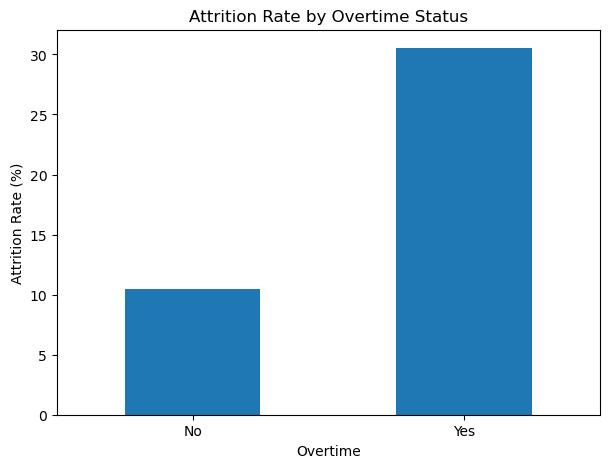

In [93]:
overtime_attrition = pd.crosstab(
    df['OverTime_Label'],
    df['Attrition_Label'],
    normalize='index'
) * 100

overtime_attrition['Yes'].plot(kind='bar', figsize=(7,5))

plt.title('Attrition Rate by Overtime Status')
plt.xlabel('Overtime')
plt.ylabel('Attrition Rate (%)')
plt.xticks(rotation=0)
plt.show()

In [94]:
overtime_attrition

Attrition_Label,No,Yes
OverTime_Label,,
No,89.563567,10.436433
Yes,69.471154,30.528846


#### Insight:
Employees who work overtime have much higher attrition than those who do not. 

#### Recommendation:
HR should review overtime levels, workload and staffing to understand why employees are regularly working beyond normal hours.

 #### Frequent business travel is associated with higher attrition

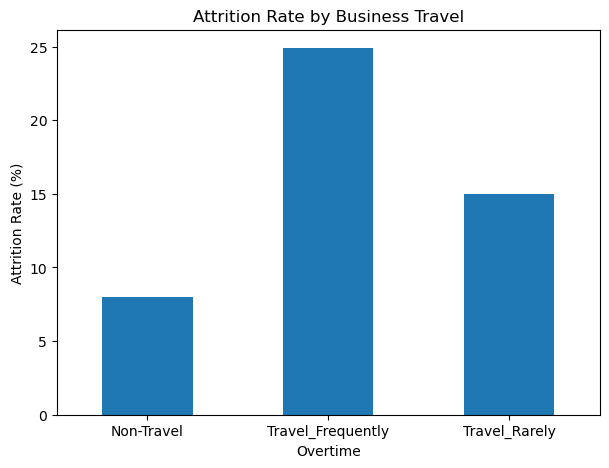

In [107]:
overtime_attrition = pd.crosstab(
    df['BusinessTravel'],
    df['Attrition_Label'],
    normalize='index'
) * 100

overtime_attrition['Yes'].plot(kind='bar', figsize=(7,5))

plt.title('Attrition Rate by Business Travel')
plt.xlabel('Overtime')
plt.ylabel('Attrition Rate (%)')
plt.xticks(rotation=0)
plt.show()

#### Insight:
Employees who travel frequently have higher attrition than those who travel rarely or do not travel.

#### Recommendation:
Review the frequency and demands of business travel and assess whether travel schedules are affecting employee workload and work-life balance.

#### Younger employees working overtime are particularly at risk

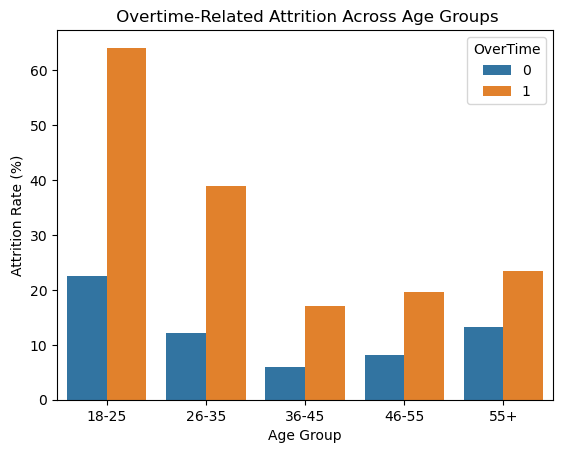

In [96]:
age_overtime = pd.crosstab(
    [df['AgeGroup'], df['OverTime']],
    df['Attrition_Label'],
    normalize='index'
) * 100

age_overtime = age_overtime.reset_index()

sns.barplot(
    data=age_overtime,
    x='AgeGroup',
    y='Yes',
    hue='OverTime'
)

plt.title(' Overtime-Related Attrition Across Age Groups')
plt.xlabel('Age Group')
plt.ylabel('Attrition Rate (%)')
plt.show()

#### Insight:
Employees aged 18–25 who work overtime have a 64.1% attrition rate, compared with 22.6% among those who do not work overtime.

#### Recommendation:
Introduce early-career support such as mentoring, clearer career paths and regular check-ins, while also monitoring workload and overtime among younger employees.

#### Some job roles require targeted attention

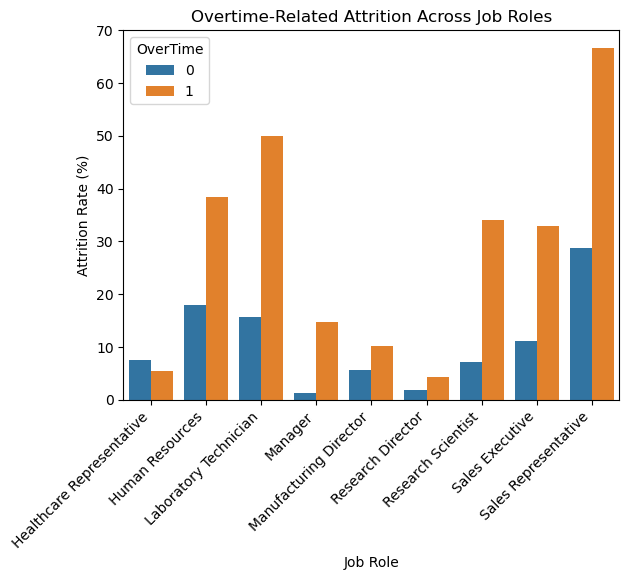

In [97]:
role_overtime = pd.crosstab(
    [df['JobRole'], df['OverTime']],
    df['Attrition_Label'],
    normalize='index'
) * 100

role_overtime = role_overtime.reset_index()

sns.barplot(
    data=role_overtime,
    x='JobRole',
    y='Yes',
    hue='OverTime'
)

plt.title('Overtime-Related Attrition Across Job Roles')
plt.xlabel('Job Role')
plt.ylabel('Attrition Rate (%)')
plt.xticks(rotation=45, ha='right')
plt.show()

#### Insight:
Sales Representatives who work overtime have a 66.7% attrition rate, while Laboratory Technicians also show high attrition when working overtime.

#### Recommendation:
HR should investigate workload, targets, management support, compensation and career progression in these roles before designing targeted retention measures.

#### Which Job Roles Are Most at Risk of Attrition?

In [98]:
predicted_role = (
    result.groupby('JobRole')['Predicted_Attrition']
    .mean()
    .mul(100)
    .sort_values()
)
predicted_role 

JobRole
Manager                       0.000000
Healthcare Representative    11.538462
Manufacturing Director       14.814815
Research Director            16.666667
Research Scientist           35.937500
Sales Executive              39.436620
Human Resources              50.000000
Laboratory Technician        56.756757
Sales Representative         68.421053
Name: Predicted_Attrition, dtype: float64

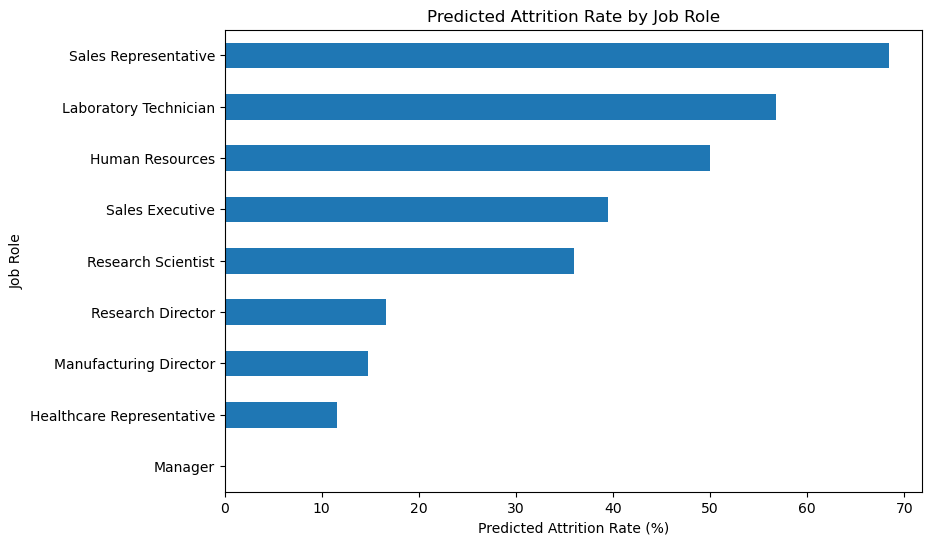

In [99]:
predicted_role.plot(
    kind='barh',
    figsize=(9,6)
)

plt.title('Predicted Attrition Rate by Job Role')
plt.xlabel('Predicted Attrition Rate (%)')
plt.ylabel('Job Role')
plt.show()

#### Insight:
Sales Representatives have the highest predicted attrition (68.4%), followed by Laboratory Technicians (56.8%) and Human Resources (50.0%).

#### Recommendation:
Prioritise these roles for further investigation, focusing on workload, management, compensation and career progression.

####  Retention may require more than financial rewards

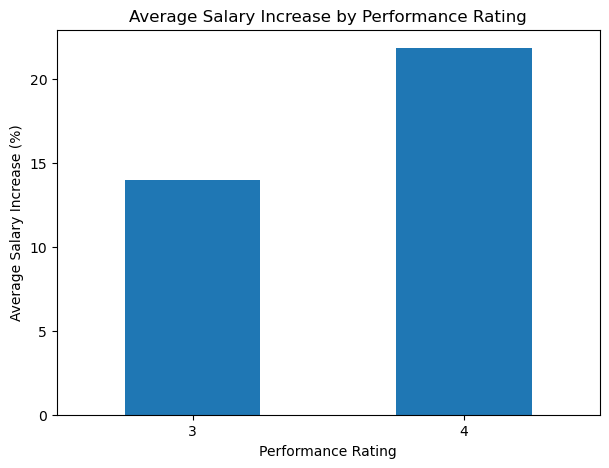

In [100]:
salary_by_performance = (
    df.groupby('PerformanceRating')['PercentSalaryHike']
    .mean()
)

salary_by_performance.plot(
    kind='bar',
    figsize=(7,5)
)

plt.title('Average Salary Increase by Performance Rating')
plt.xlabel('Performance Rating')
plt.ylabel('Average Salary Increase (%)')
plt.xticks(rotation=0)
plt.show()

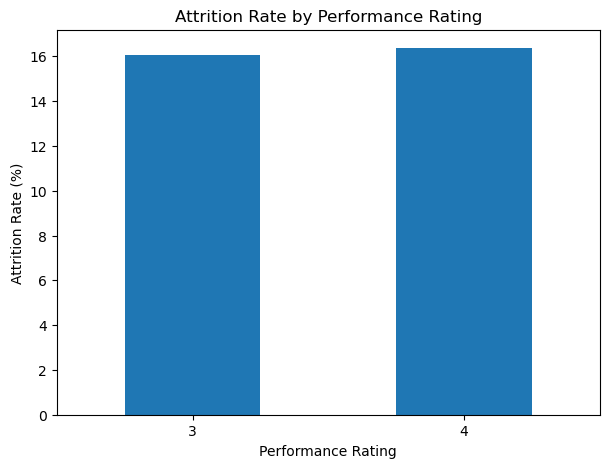

In [101]:
performance_attrition = pd.crosstab(
    df['PerformanceRating'],
    df['Attrition_Label'],
    normalize='index'
) * 100

performance_attrition['Yes'].plot(
    kind='bar',
    figsize=(7,5)
)

plt.title('Attrition Rate by Performance Rating')
plt.xlabel('Performance Rating')
plt.ylabel('Attrition Rate (%)')
plt.xticks(rotation=0)
plt.show()

#### Insight:
Higher-performing employees receive larger salary increases, but attrition rates are relatively similar across performance groups. This suggests that financial rewards alone may not explain employee retention.

#### Recommendation:
Alongside performance-based pay, the company should strengthen career progression, employee involvement, job satisfaction and other aspects of the employee experience.

In [102]:
df.to_csv("exported.csv", index=False)

In [106]:
age_pred.to_csv("Test_pred", index = False)